# Taxa Assemblages Pattern Analysis

## Table of Contents

1. [Select Reference Sites](#select-reference-sites)
   - Identify least-polluted sites as training data for hierarchical clustering
   - Visualize spatial distribution and pollution score distribution (ECDF)
   - Map chemical concentration levels

2. [Validate the Representativeness of References](#validate-the-representative-of-references-in-environmental-taxa-space)
   - Compare environmental feature distributions (reference vs. all sites)
   - Compare taxa abundance distributions (reference vs. test sites)
   - Statistical testing for representativeness

3. [Q-Mode Analysis: Dissimilarity Matrix on Species Data of Sites](#q-mode-association-measures-dissimilarity-matrix-on-sites-of-species-data)
   - Overview of distance measures for ecological data
   - Addressing the double-zero problem in community data
   
4. [Asymmetrical Association Measures](#asymmetrical-association-measures-on-sites-of-species-data-address-double-zero-problem)
   - [Chord Normalization](#chord-normalization)
     - Unit hypersphere transformation
     - Chord distance matrix computation
   - [Hellinger Normalization](#hellinger-normalization)
     - Square-root weighted transformation
     - Hellinger distance matrix computation

5. [Preview: Hierarchical Clustering on Asymmetrical Association Measures](#preview-hierarchical-clustering-on-asymmetrical-association-measures)
   - Ward's method on Chord distance matrix
   - Ward's method on Hellinger distance matrix
   - [Check Spatial and Environmental Conditions](#check-the-spatial-and-env-feature-conditions)
     - Spatial distribution of taxa assemblage groups
     - Environmental feature comparisons across groups

6. [Deciding a Good Typology for Hierarchical Clustering Results](#deciding-a-good-typology-for-hierarchical-clustering-results)
   - [Choose the Dissimilarity Measure and Clustering Algorithm](#choose-the-dissimilarity-measure-and-clustering-algorithm)
     - Compare linkage methods: single, complete, average, Ward
     - Cophenetic correlation analysis
     - Scatter plots of original vs. cophenetic distances
   - [Choose a Cut Level (Internal Validation)](#choose-a-cut-level-internal-validation)
     - Fusion level plots
     - Visualization of cluster formation at each merge step
   - [Provide an Ecological Interpretation (External Validation)](#provide-an-ecological-interpretation-external-validation)
     - [Check ANOVA Assumptions Across Groups](#check-the-anova-assumptions-across-the-groups)
       - Normality tests (Shapiro-Wilk, Anderson-Darling)
       - Homogeneity of variance tests (Levene's test)
       - Diagnostic visualizations (Q-Q plots, residual plots, boxplots)
     - [Box-Cox Transformation](#box-cox-transformation-to-the-environmental-features-and-check-anova-assumptions-again)
       - Optimal lambda parameter search
       - Re-assessment of ANOVA assumptions on transformed data
       - Comparison of assumption satisfaction (raw vs. transformed)
     - [ANOVA on Box-Cox Transformed Features](#anova-on-box-cox-transformed-habitat-features-across-the-clusters)
       - One-way ANOVA tests across taxa assemblage groups
       - Identification of significant environmental drivers
       - Interpretation of ecological patterns

## Select reference sites

With the end of 02_Contamination_Assessment notebook, every site has a contaminatoin score that can be used to rank their pollution compareably. Read the data and select the top $p$ **least-pollutant sites** as prinstine sites for studying 'environmental-taxa' equation is feasible.

In [1]:
# read the data with pollution score
import pandas as pd 
from zci.data_process.dataframe_ops import get_block, concat_blocks

# read the data with pollution score
data = pd.read_excel("../data/processed/contamination_assessment_scores_11_26.xlsx",
                     header=[0,1,2],
                     index_col=0)

# Remove multi-index levels from columns
raw_data = data.copy()
raw_data.columns = raw_data.columns.droplevel([0, 1])

data.head()

block     sample_info                           environmental            \
subblock          raw                                     raw             
var          Latitude Longitude Waterbody  Year       LOI (%) MPS (Phi)   
StationID                                                                 
A10          42.90455 -82.46760       SCR  2004      3.436193  1.734259   
A23          42.56658 -82.57595       LSC  2004      3.226637  1.969984   
A27          42.56007 -82.42132       LSC  2004      2.802642  1.319519   
A28          42.54577 -82.42073       LSC  2004      3.201399  1.398687   
A29          42.51440 -82.43462       LSC  2004      6.180718  1.065748   

block                                                                      \
subblock                                                                    
var       Measured Depth (m) Temperature (oC) Velocity  at bottom (m/sec)   
StationID                                                                   
A10                      1.8            19.17                         NaN   
A23                      3.0            19.10                         NaN   
A27                      1.0            18.40                         NaN   
A28                      0.5            18.90                         NaN   
A29                      0.5            19.30                         NaN   

block                             ...          taxa                        \
subblock                          ...           raw                         
var       Water DO Bottom (mg/L)  ...      Hydrozoa  Nematoda Oligochaeta   
StationID                         ...                                       
A10                        10.21  ...  3.203427e-16  1.727234    6.576942   
A23                        10.09  ...  3.203427e-16  2.427993    5.872905   
A27                        10.30  ...  3.203427e-16  1.802219    6.402280   
A28                        12.80  ...  3.203427e-16  2.771800    5.867874   
A29                         9.70  ...  3.203427e-16  4.616441    5.181664   

block                                                   2008_results        \
subblock                                                 DR_clusters         
var       Other Trichoptera   Sphaeriidae   Turbellaria   DR_cluster if_RF   
StationID                                                                    
A10            3.203427e-16  3.203427e-16  3.203427e-16            0     0   
A23            3.203427e-16  1.022139e+00  5.997595e-01            0     0   
A27            1.580169e+00  1.317615e+00  9.964067e-01            0     0   
A28            2.049287e+00  2.863547e+00  3.203427e-16            0     0   
A29            3.203427e-16  3.203427e-16  3.203427e-16            0     0   

block                       pollution  
subblock  corridor_clusters     11_26  
var        corridor_cluster    SumRel  
StationID                              
A10                       1  0.239233  
A23                       1  1.844213  
A27                       1  1.025010  
A28                       1 -0.251189  
A29                       1  1.149254  

[5 rows x 60 columns]

Subjectively choose the first $p$ percent sites as reference sites.

In [2]:
# set p percentage of sites to select as reference
p = 50

In [3]:
# choose p% lowest scores sites as reference sites
pollution_scores = raw_data['SumRel']
n_reference_sites = int(len(pollution_scores) * p / 100)
reference_sites = pollution_scores.nsmallest(n_reference_sites)
raw_reference_data = raw_data.loc[reference_sites.index]
reference_data = data.loc[reference_sites.index]

print(f"Selected {n_reference_sites} reference sites ({p}% of {len(raw_data)} total sites)")
print(f"Pollution scores range: {reference_sites.min():.3f} to {reference_sites.max():.3f}")
print(f"Reference sites: {list(reference_sites.index)}")

Selected 52 reference sites (50% of 104 total sites)
Pollution scores range: -3.653 to -0.267
Reference sites: ['S54', 'S70', 'S96', 'S72', 'S65', 'S74', 'S53', 'DCC2', 'S51', 'GL1', 'A66', 'S93', 'S41', 'S69', 'S8', 'S60', 'S68', 'S28', 'S1', 'S39', 'S37', 'S50', 'S102', 'S63', 'A5', 'S38', 'S28(5)', 'S56', 'S67', 'S21(5)', 'S20', 'S44', 'S25', 'S17', 'S62', 'S18', 'S9', 'S49', 'S47', 'S82', 'S22', 'S90', 'S101', 'S45', 'A53', 'S81', 'S79', 'A6', 'S83', 'S43', 'S87', 'S95']


Before finally decide a good $p$ value, we can first visualize the pollution step plot to choose an as higher $p$ as possible to have more reference sites.

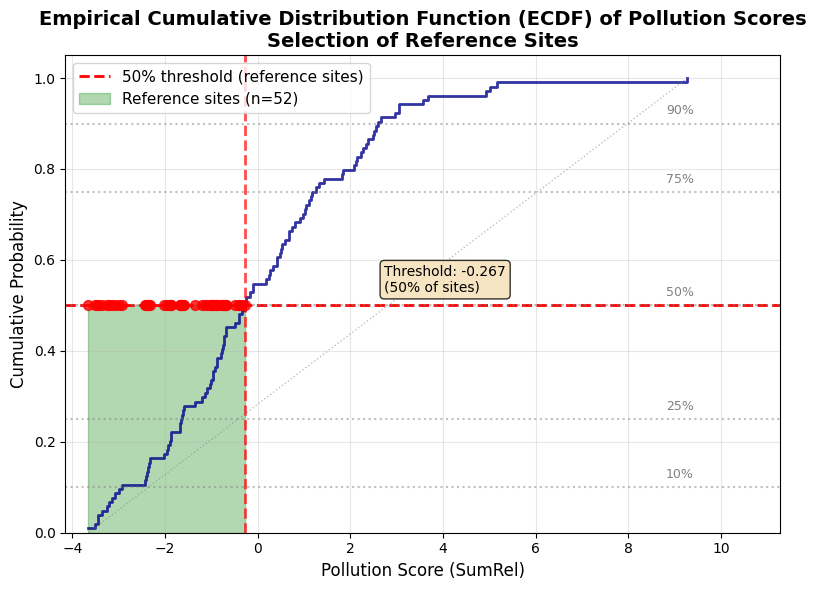

Pollution Score Distribution Summary:
Total sites: 104
Score range: -3.653 to 9.276
Reference sites threshold: -0.267
Reference sites scores range: -3.653 to -0.267

Percentiles:
  10th percentile: -2.783
  25th percentile: -1.645
  50th percentile: -0.259
  75th percentile: 1.200
  90th percentile: 2.580
  95th percentile: 3.499


In [4]:
# create step plot to visualize the empirical cumulative density function of pollution scores
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Sort pollution scores for CDF
sorted_scores = raw_data['SumRel'].sort_values()

# Create empirical CDF
n_sites = len(sorted_scores)
cumulative_prob = np.arange(1, n_sites + 1) / n_sites

# Plot the ECDF as a step plot
plt.step(sorted_scores, cumulative_prob, where='post', linewidth=2, color='darkblue', alpha=0.8)

# Add reference sites threshold line
reference_threshold = reference_sites.max()
reference_percentile = p / 100

plt.axhline(y=reference_percentile, color='red', linestyle='--', linewidth=2, 
           label=f'{p}% threshold (reference sites)')
plt.axvline(x=reference_threshold, color='red', linestyle='--', linewidth=2, alpha=0.7)

# Highlight reference sites region
plt.fill_between(sorted_scores[sorted_scores <= reference_threshold], 
                 0, reference_percentile, alpha=0.3, color='green', 
                 label=f'Reference sites (n={n_reference_sites})')

# Add markers for selected reference sites
plt.scatter(reference_sites, [p/100] * len(reference_sites), 
           color='red', s=50, zorder=5, alpha=0.8)

# Add a diagonal line of y=x for reference
plt.plot([sorted_scores.min(), sorted_scores.max()], 
         [0, 1], color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Styling
plt.xlabel('Pollution Score (SumRel)', fontsize=12)
plt.ylabel('Cumulative Probability', fontsize=12)
plt.title('Empirical Cumulative Distribution Function (ECDF) of Pollution Scores\nSelection of Reference Sites', 
         fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Add text annotations
plt.text(reference_threshold + 3, reference_percentile + 0.03, 
         f'Threshold: {reference_threshold:.3f}\n({p}% of sites)', 
         fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Add percentile markers on y-axis
percentiles = [10, 25, 50, 75, 90]
for pct in percentiles:
    score_at_pct = np.percentile(sorted_scores, pct)
    plt.axhline(y=pct/100, color='gray', linestyle=':', alpha=0.5)
    plt.text(sorted_scores.max() * 0.95, pct/100 + 0.02, f'{pct}%', 
             fontsize=9, color='gray')

plt.ylim(0, 1.05)
plt.xlim(sorted_scores.min() - 0.5, sorted_scores.max() + 2)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Pollution Score Distribution Summary:")
print(f"Total sites: {n_sites}")
print(f"Score range: {sorted_scores.min():.3f} to {sorted_scores.max():.3f}")
print(f"Reference sites threshold: {reference_threshold:.3f}")
print(f"Reference sites scores range: {reference_sites.min():.3f} to {reference_sites.max():.3f}")
print(f"\nPercentiles:")
for pct in [10, 25, 50, 75, 90, 95]:
    score = np.percentile(sorted_scores, pct)
    print(f"  {pct}th percentile: {score:.3f}")

Visualize where the $p\%$ sites are and levels of their raw chemical concentrations.

In [5]:
# a function to plot the spatial distribution and comparative barplot of the references
import seaborn as sns
from scipy.stats import f_oneway
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# define a function to read the shp files and quickly plot the lake and river maps
def plot_rivers_lakes(ax = None, annotating = False):
    """Plot the Detroit River with adjacent lakes."""
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure
        
    # read the two shape files of the lakes
    lake_stclair = gpd.read_file("../data/maps/lake_stclair/lake_stclair.shp")
    lake_erie = gpd.read_file("../data/maps/lake_erie/lake_erie.shp")
    detroit_river = gpd.read_file("../data/maps/detroit_river_aoc_shapefile/AOC_MI_Detroit_2021.shp")
    stclair_river = gpd.read_file("../data/maps/aoc_mi_stclair_2021/AOC_MI_StClair_2021.shp")
    lake_huron = gpd.read_file("../data/maps/lake_huron/lake_huron.shp")
    
    # plot the Detroit River and the lakes
    lake_stclair.plot(ax=ax, color='lightblue', edgecolor='none', alpha=0.5)
    lake_erie.plot(ax=ax, color='lightblue', edgecolor='none', alpha=0.5)
    lake_huron.plot(ax=ax, color='lightblue', edgecolor='none', alpha=0.5)
    detroit_river.plot(ax=ax, color='lightblue', edgecolor='none')
    stclair_river.plot(ax=ax, color='lightblue', edgecolor='none')
    ax.set_title("The Huron-Erie Corridor")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_ylim(42, 43.1)  # Set y-limits to focus on North America
    ax.set_xlim(-83.3, -82.3)  # Set x-limits to focus on North America
    if annotating:
        ax.text(-83.0, 42.2, 'Detroit River', fontsize=8, color = 'gray', style='italic') 
        ax.text(-82.85, 42.9, 'St. Clair River', fontsize=8, color = 'gray', style='italic')
        ax.text(-82.55, 42.05, 'Lake Erie', fontsize=8, color = 'gray', style='italic')
        ax.text(-83.0, 42.5, 'Lake St. Clair', fontsize=8, color = 'gray', style='italic')
        ax.text(-82.6, 43.05, 'Lake Huron', fontsize=8, color = 'gray', style='italic')
    return fig, ax

def plot_feature_analysis(df, feature_name, lat_col='Latitude', lon_col='Longitude', waterbody_col='Waterbody'):
    """
    Plot a specific habitat feature's spatial distribution and statistical analysis.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the data
    feature_name : str
        Name of the feature column to analyze
    lat_col : str
        Name of the latitude column (default: 'Latitude')
    lon_col : str
        Name of the longitude column (default: 'Longitude')
    waterbody_col : str
        Name of the waterbody column (default: 'Waterbody')
    """
    
    # Create a figure with three subplots: left for map, right side split into two
    fig = plt.figure(figsize=(10, 6), dpi=300)

    # Create subplot layout: left panel takes 1/2 width, right panel split into 2 rows
    ax1 = plt.subplot2grid((2, 2), (0, 0), rowspan=2)  # Map spans full left side (1/2 width)
    ax2 = plt.subplot2grid((2, 2), (0, 1))  # Upper right: ridge plot comparison
    ax3 = plt.subplot2grid((2, 2), (1, 1))  # Lower right: ANOVA test results

    # Left panel: Spatial distribution map
    plot_rivers_lakes(ax=ax1, annotating=True)
    # Normalize the feature values to create relative sizes
    feature_values = df[feature_name]
    normalized_sizes = ((feature_values - feature_values.min()) / 
                       (feature_values.max() - feature_values.min()) * 100 + 5)
    
    sc = ax1.scatter(df[lon_col], df[lat_col], c=df[feature_name], 
                     s=normalized_sizes, cmap='viridis', alpha=0.7)
    ax1.set_title(f"Spatial Distribution of {feature_name}", fontsize=14, fontweight='bold')
    ax1.grid(linestyle='--', alpha=0.5)

    # Add colorbar for the scatter plot
    cbar = plt.colorbar(sc, ax=ax1, shrink=0.8)
    cbar.set_label(feature_name, fontsize=12)

    # Upper right: Ridge plot-style comparison across waterbodies
    waterbodies = df[waterbody_col].unique()

    # Create blue gradient colors
    n_bodies = len(waterbodies)
    colors = plt.cm.Blues(np.linspace(0.3, 0.9, n_bodies))

    # Set up the ridge plot parameters
    ridge_height = 0.8  # Height of each ridge
    ridge_spacing = 1.0  # Vertical spacing between ridges
    baseline_offset = 0.1  # Small offset from baseline

    # Clear the axis and set up for ridge plot
    ax2.clear()

    # Create ridge plot with proper stacking
    for i, wb in enumerate(waterbodies):
        data_wb = df[df[waterbody_col] == wb][feature_name].dropna()
        if len(data_wb) > 1:
            # Create smooth density curve using Gaussian KDE
            kde = gaussian_kde(data_wb)
            
            # Create x values for smooth curve
            x_min, x_max = data_wb.min(), data_wb.max()
            x_range = x_max - x_min
            x_smooth = np.linspace(x_min - 0.1*x_range, x_max + 0.1*x_range, 200)
            
            # Calculate density values
            density = kde(x_smooth)
            
            # Normalize density to ridge height
            normalized_density = (density / density.max()) * ridge_height
            
            # Calculate y position for this ridge (bottom to top)
            y_baseline = i * ridge_spacing
            y_values = y_baseline + normalized_density + baseline_offset
            
            # Create the filled area
            ax2.fill_between(x_smooth, y_baseline + baseline_offset, y_values, 
                            color=colors[i], alpha=0.8, edgecolor='white', linewidth=0.5)
            
            # Add a subtle baseline for each ridge
            ax2.axhline(y=y_baseline + baseline_offset, color='lightgray', 
                       linestyle='-', linewidth=0.5, alpha=0.7)

    # Set up the y-axis
    ax2.set_ylim(-0.2, len(waterbodies) * ridge_spacing + 0.5)
    ax2.set_yticks([i * ridge_spacing + baseline_offset + ridge_height/2 for i in range(len(waterbodies))])
    ax2.set_yticklabels(waterbodies, fontsize=11)

    # Style the plot
    ax2.set_title(f"Overlapping densities ('ridge plot')", fontsize=10, fontweight='bold')
    ax2.set_xlabel(feature_name, fontsize=11)
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    # Lower right: ANOVA test results with bar plot
    waterbody_groups = [df[df[waterbody_col] == wb][feature_name].dropna() 
                       for wb in waterbodies]
    f_stat, p_value = f_oneway(*waterbody_groups)

    # Calculate means and standard errors
    means = [group.mean() for group in waterbody_groups]
    std_errors = [group.std() / np.sqrt(len(group)) for group in waterbody_groups]

    # Create bar plot with error bars using the same blue gradient
    bars = ax3.bar(waterbodies, means, yerr=std_errors, 
                   alpha=0.8, color=colors, capsize=5, 
                   error_kw={'linewidth': 2, 'markeredgewidth': 2})

    # Add value labels on bars
    for i, (bar, mean) in enumerate(zip(bars, means)):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + std_errors[i] + height*0.02,
                 f'{mean:.2f}', ha='center', va='bottom', fontweight='bold')

    ax3.set_title(f"ANOVA Test: Mean {feature_name} by Waterbody\nF={f_stat:.3f}, p={p_value:.4f}", 
                  fontsize=10, fontweight='bold')
    ax3.set_ylabel(f"Mean {feature_name} ± SE", fontsize=11)
    ax3.set_xlabel("Waterbody", fontsize=11)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.spines['left'].set_visible(False)

    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.4)

    plt.show()
    
    return fig, f_stat, p_value

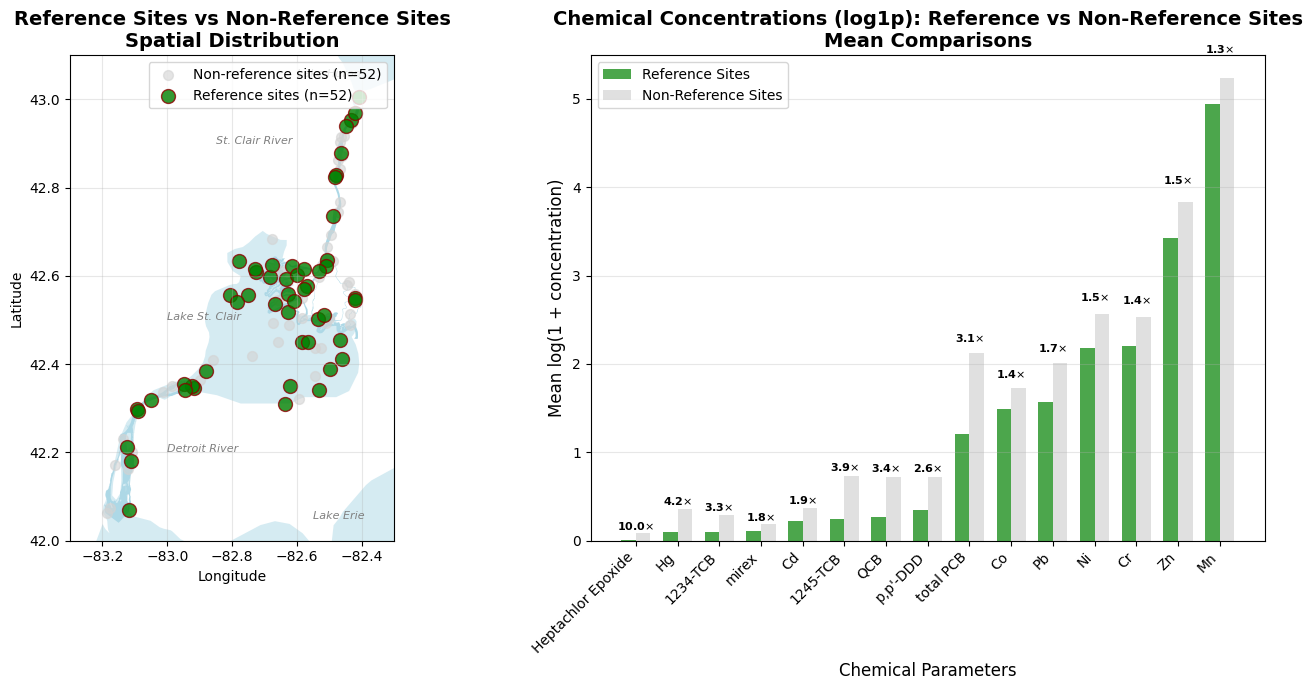


Reference Sites Summary:
Number of sites: 52
Pollution score range: -3.653 to -0.267
Waterbodies represented: {'LSC': 34, 'DR': 10, 'SCR': 8}

Non-Reference Sites Summary:
Number of sites: 52
Pollution score range: -0.251 to 9.276


In [6]:
# Create a comprehensive comparison plot of reference vs non-reference sites
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Left panel: Spatial distribution showing reference vs non-reference sites
plot_rivers_lakes(ax=ax1, annotating=True)

# Identify non-reference sites
non_reference_sites = raw_data.loc[~raw_data.index.isin(reference_sites.index)]

# Plot non-reference sites in gray
ax1.scatter(non_reference_sites['Longitude'], non_reference_sites['Latitude'], 
           c='lightgray', s=50, alpha=0.6, label=f'Non-reference sites (n={len(non_reference_sites)})')

# Plot reference sites in green
ax1.scatter(raw_reference_data['Longitude'], raw_reference_data['Latitude'], 
           c='green', s=100, alpha=0.8, edgecolors='darkred', linewidths=1,
           label=f'Reference sites (n={n_reference_sites})')

ax1.set_title('Reference Sites vs Non-Reference Sites\nSpatial Distribution', 
             fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
# Right panel: Chemical comparison between reference and non-reference sites
# Select key chemical columns (excluding biological and coordinate data)
chemical_cols = ['Heptachlor Epoxide', "p,p'-DDD", 'QCB', '1234-TCB', 'Cd', 'Co', 'Cr', 'mirex', 'total PCB', 
                'Hg', 'Mn', 'Ni', 'Pb', 'Zn', '1245-TCB']

# Apply log(1 + x) transformation to concentrations before computing means
ref_log1p = np.log1p(raw_reference_data[chemical_cols])
non_ref_log1p = np.log1p(non_reference_sites[chemical_cols])

# Calculate means for reference sites and sort by absolute values (ascending)
ref_means_for_sorting = ref_log1p.mean()
chemical_cols = ref_means_for_sorting.abs().sort_values().index.tolist()

# Calculate means for both groups in log1p scale
ref_means = ref_log1p[chemical_cols].mean()
non_ref_means = non_ref_log1p[chemical_cols].mean()

# Create comparison DataFrame in log1p scale
comparison_data = pd.DataFrame({
    'Reference Sites (log1p)': ref_means,
    'Non-Reference Sites (log1p)': non_ref_means
})

# Create bar plot
x_pos = np.arange(len(chemical_cols))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, comparison_data['Reference Sites (log1p)'], 
               width, label='Reference Sites', color='green', alpha=0.7)
bars2 = ax2.bar(x_pos + width/2, comparison_data['Non-Reference Sites (log1p)'], 
               width, label='Non-Reference Sites', color='lightgray', alpha=0.7)

# Customize the plot
ax2.set_xlabel('Chemical Parameters', fontsize=12)
ax2.set_ylabel('Mean log(1 + concentration)', fontsize=12)
ax2.set_title('Chemical Concentrations (log1p): Reference vs Non-Reference Sites\nMean Comparisons', 
             fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(chemical_cols, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars for key differences (in log1p scale)
for i, (ref_val, non_ref_val) in enumerate(zip(comparison_data['Reference Sites (log1p)'], 
                                              comparison_data['Non-Reference Sites (log1p)'])):
    # Compare on original scale via ratio for interpretability
    ref_orig = np.expm1(ref_val)
    non_ref_orig = np.expm1(non_ref_val)
    ratio = non_ref_orig / ref_orig if ref_orig != 0 else float('inf')
    if ratio > 1 or ratio < 0.5:  # Show label if difference is substantial
        ax2.text(i, max(ref_val, non_ref_val) * 1.05, f'{ratio:.1f}$\\times$', 
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics in both original and log1p scales
print(f"\nReference Sites Summary:")
print(f"Number of sites: {len(raw_reference_data)}")
print(f"Pollution score range: {raw_reference_data['SumRel'].min():.3f} to {raw_reference_data['SumRel'].max():.3f}")
print(f"Waterbodies represented: {raw_reference_data['Waterbody'].value_counts().to_dict()}")

print(f"\nNon-Reference Sites Summary:")
print(f"Number of sites: {len(non_reference_sites)}")
print(f"Pollution score range: {non_reference_sites['SumRel'].min():.3f} to {non_reference_sites['SumRel'].max():.3f}")

## Validate the representative of references in environmental-taxa space

In estimating the environmental-taxa relationship, the samples should be representative, randomized chosen from the env-taxa space. 

That is, when setting the least-pollutant constraint, the selected references are confined and worth checking their representativeness for the rest (test) sites.

**References sites vs Test sites** (in env-taxa space)

Chech the habitat features first.

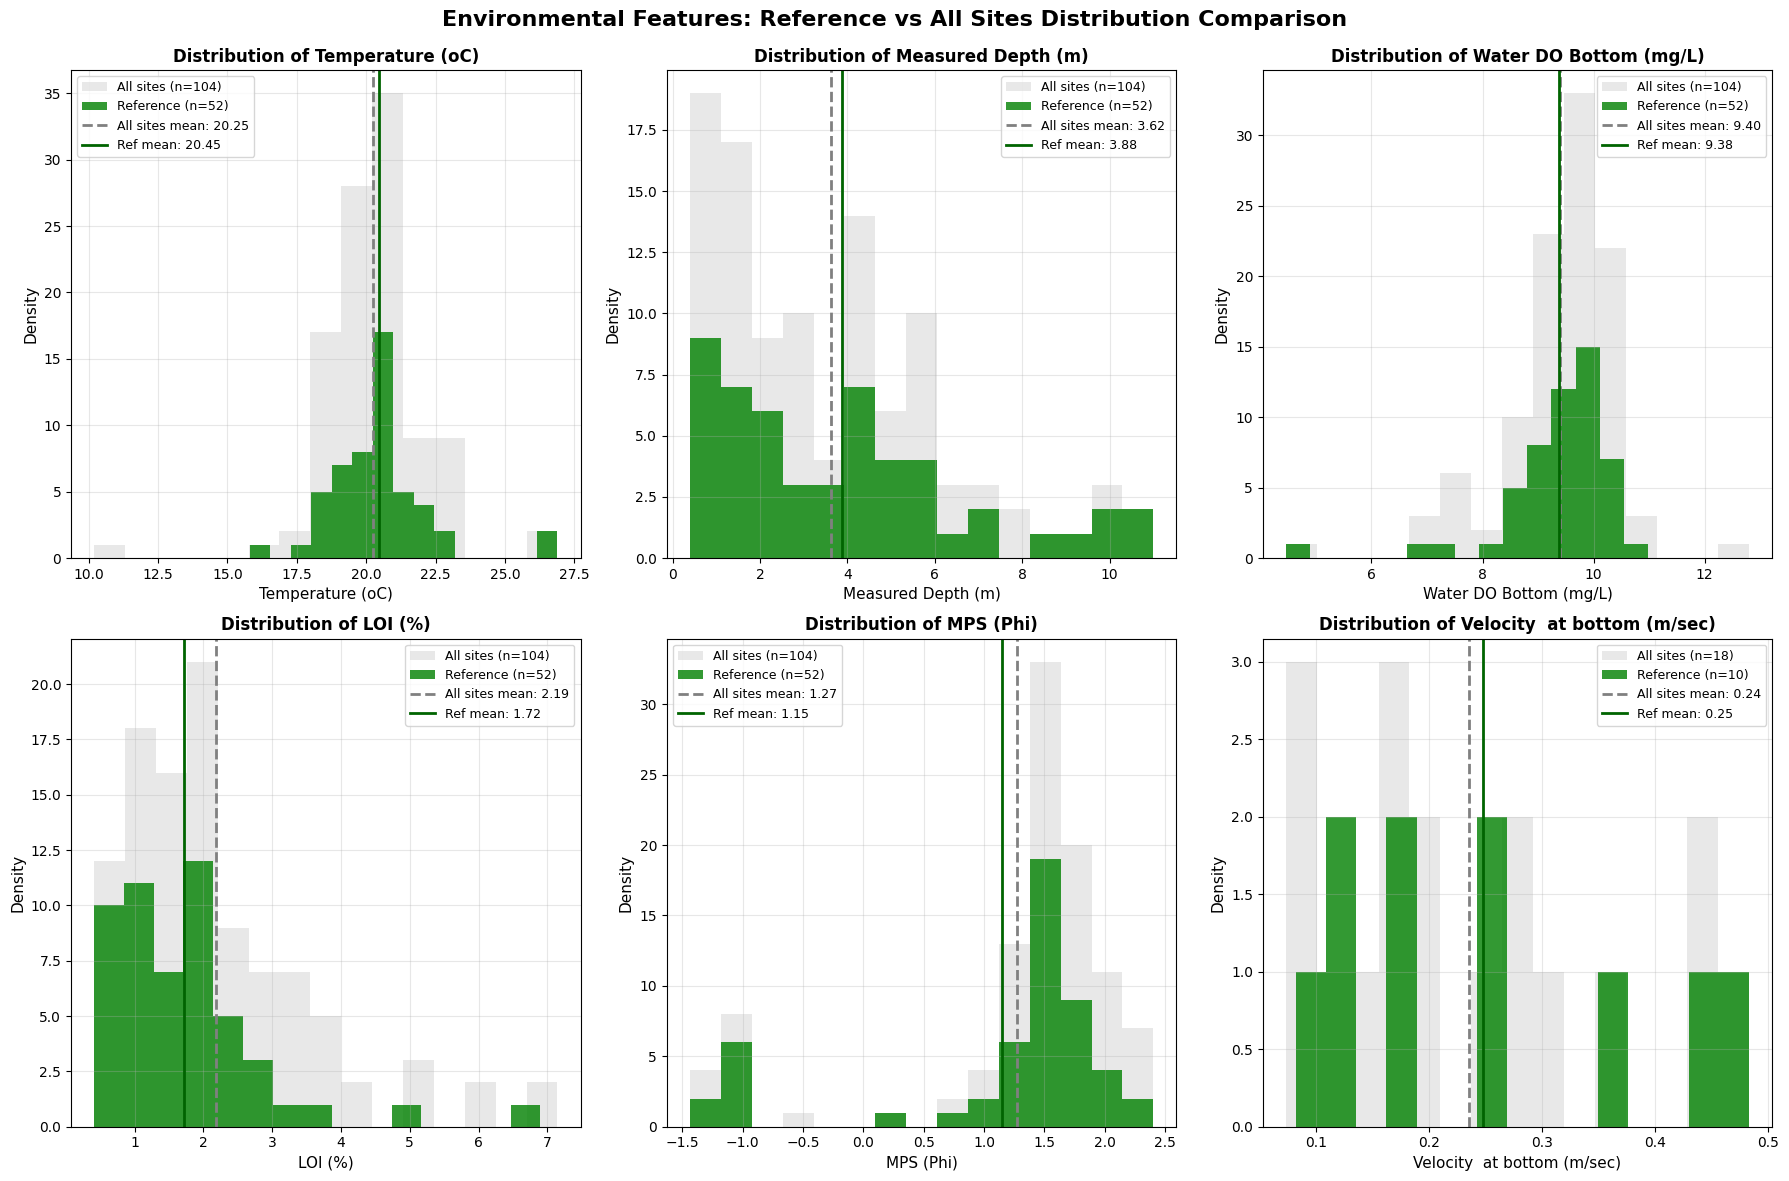

Environmental Features Summary (Reference vs All Sites):
Environmental Features Statistical Comparison (Reference vs All Sites)
Feature                   Ref Mean   Ref Std    All Mean   All Std    T-Stat     P-Value      Sig  
----------------------------------------------------------------------------------------------------
Temperature (oC)          20.449     1.830      20.254     1.927      0.616      0.5393       NS   
Measured Depth (m)        3.875      2.851      3.623      2.600      0.535      0.5936       NS   
Water DO Bottom (mg/L)    9.380      1.015      9.402      1.057      -0.124     0.9017       NS   
LOI (%)                   1.718      1.134      2.188      1.379      -2.264     0.0254       *    
MPS (Phi)                 1.145      1.045      1.273      0.971      -0.735     0.4642       NS   
Velocity  at bottom (m/sec) 0.247      0.141      0.235      0.129      0.224      0.8257       NS   

Significance levels: *** p<0.001, ** p<0.01, * p<0.05, NS p>=0.05

S

In [7]:
# compare the distributions of reference and all sites for environmental features
from scipy.stats import ttest_ind

# Select environmental features for analysis (excluding water velocity due to missing data)
env_features = ['Temperature (oC)', 'Measured Depth (m)', 'Water DO Bottom (mg/L)', 'LOI (%)', 'MPS (Phi)', 'Velocity  at bottom (m/sec)']

# Create a comprehensive visualization of environmental features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(env_features):
    ax = axes[i]
    
    # Get data for reference and all sites
    ref_data = raw_reference_data[feature].dropna()
    all_data = raw_data[feature].dropna()
    
    # Build consistent bin edges from all-data range
    bins = 15
    # Create histograms: all-sample in background, reference in front
    ax.hist(all_data, bins=bins, alpha=0.5, label=f'All sites (n={len(all_data)})', 
            color='lightgray', density=False)
    ax.hist(ref_data, bins=bins, alpha=0.8, label=f'Reference (n={len(ref_data)})', 
            color='green', density=False)
    
    # Add vertical lines for means
    ax.axvline(all_data.mean(), color='gray', linestyle='--', linewidth=2, 
               label=f'All sites mean: {all_data.mean():.2f}')
    ax.axvline(ref_data.mean(), color='darkgreen', linestyle='-', linewidth=2,
               label=f'Ref mean: {ref_data.mean():.2f}')
    
    # Styling
    ax.set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Environmental Features: Reference vs All Sites Distribution Comparison', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

# Print statistical summary
print("Environmental Features Summary (Reference vs All Sites):")
print("=" * 50)
# Create a comprehensive statistics table
stats_table = []

for feature in env_features:
    ref_vals = raw_reference_data[feature].dropna()
    all_vals = raw_data[feature].dropna()
    
    # Perform t-test (reference vs all sites)
    t_stat, p_val = ttest_ind(ref_vals, all_vals, equal_var=False)
    
    # Calculate basic statistics
    ref_mean = ref_vals.mean()
    ref_std = ref_vals.std()
    all_mean = all_vals.mean()
    all_std = all_vals.std()
    
    # Determine significance
    significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "NS"
    
    # Add to table
    stats_table.append({
        'Feature': feature,
        'Ref_Mean': ref_mean,
        'Ref_Std': ref_std,
        'All_Mean': all_mean,
        'All_Std': all_std,
        'T_Stat': t_stat,
        'P_Value': p_val,
        'Significance': significance
    })

# Convert to DataFrame for better formatting
stats_df = pd.DataFrame(stats_table)

# Print formatted table
print("Environmental Features Statistical Comparison (Reference vs All Sites)")
print("=" * 100)
print(f"{'Feature':<25} {'Ref Mean':<10} {'Ref Std':<10} {'All Mean':<10} {'All Std':<10} {'T-Stat':<10} {'P-Value':<12} {'Sig':<5}")
print("-" * 100)

for _, row in stats_df.iterrows():
    print(f"{row['Feature']:<25} {row['Ref_Mean']:<10.3f} {row['Ref_Std']:<10.3f} {row['All_Mean']:<10.3f} {row['All_Std']:<10.3f} {row['T_Stat']:<10.3f} {row['P_Value']:<12.4f} {row['Significance']:<5}")

print("\nSignificance levels: *** p<0.001, ** p<0.01, * p<0.05, NS p>=0.05")
print(f"\nSummary: {len(stats_df[stats_df['Significance'] != 'NS'])} out of {len(stats_df)} features show significant differences")

<span style="color:blue">Trap: checking the taxa abundances across reference vs text sites can be confusing and misleading..</span>

What pollution impacts more is the **multivariate community composition**, not the univariate abundance of individual taxa


In [8]:
# fetch the taxa blocks of references and all sites
taxa_block = get_block(data, "taxa")

# Align taxa for reference and all sites
taxa_ref = taxa_block.loc[reference_data.index]
taxa_all = taxa_block.copy()

# Select taxa features for analysis (non-zero variance across all sites)
taxa_features = [col for col in taxa_block.columns if taxa_block[col].var() > 0]

print(f"Number of taxa features considered: {len(taxa_features)}")

Number of taxa features considered: 16


The visualization and simple independent t-test do not dispute the "representativeness" assumption.

Therefore, we have **no reason** to say "the reference sites are not randomizedly chosen from the taxa or environmental space".

## Q-Mode (Association Measures): Dissimilarity Matrix on sites of species data

Clustering analysis **implicitly relies on dissimilarity/distance matrix** of the objects to be clustered.
The distance matrix is built upon the **chosen measurements** on objects and the way of computing distance upon it.

Doing clustering analysis on sites with species data needs to consider the ecological meanings of the measures, the raw measures always fails this requirements. Therefore, proper distance matrix needs to be constructed to include the ecological meanings correctly.

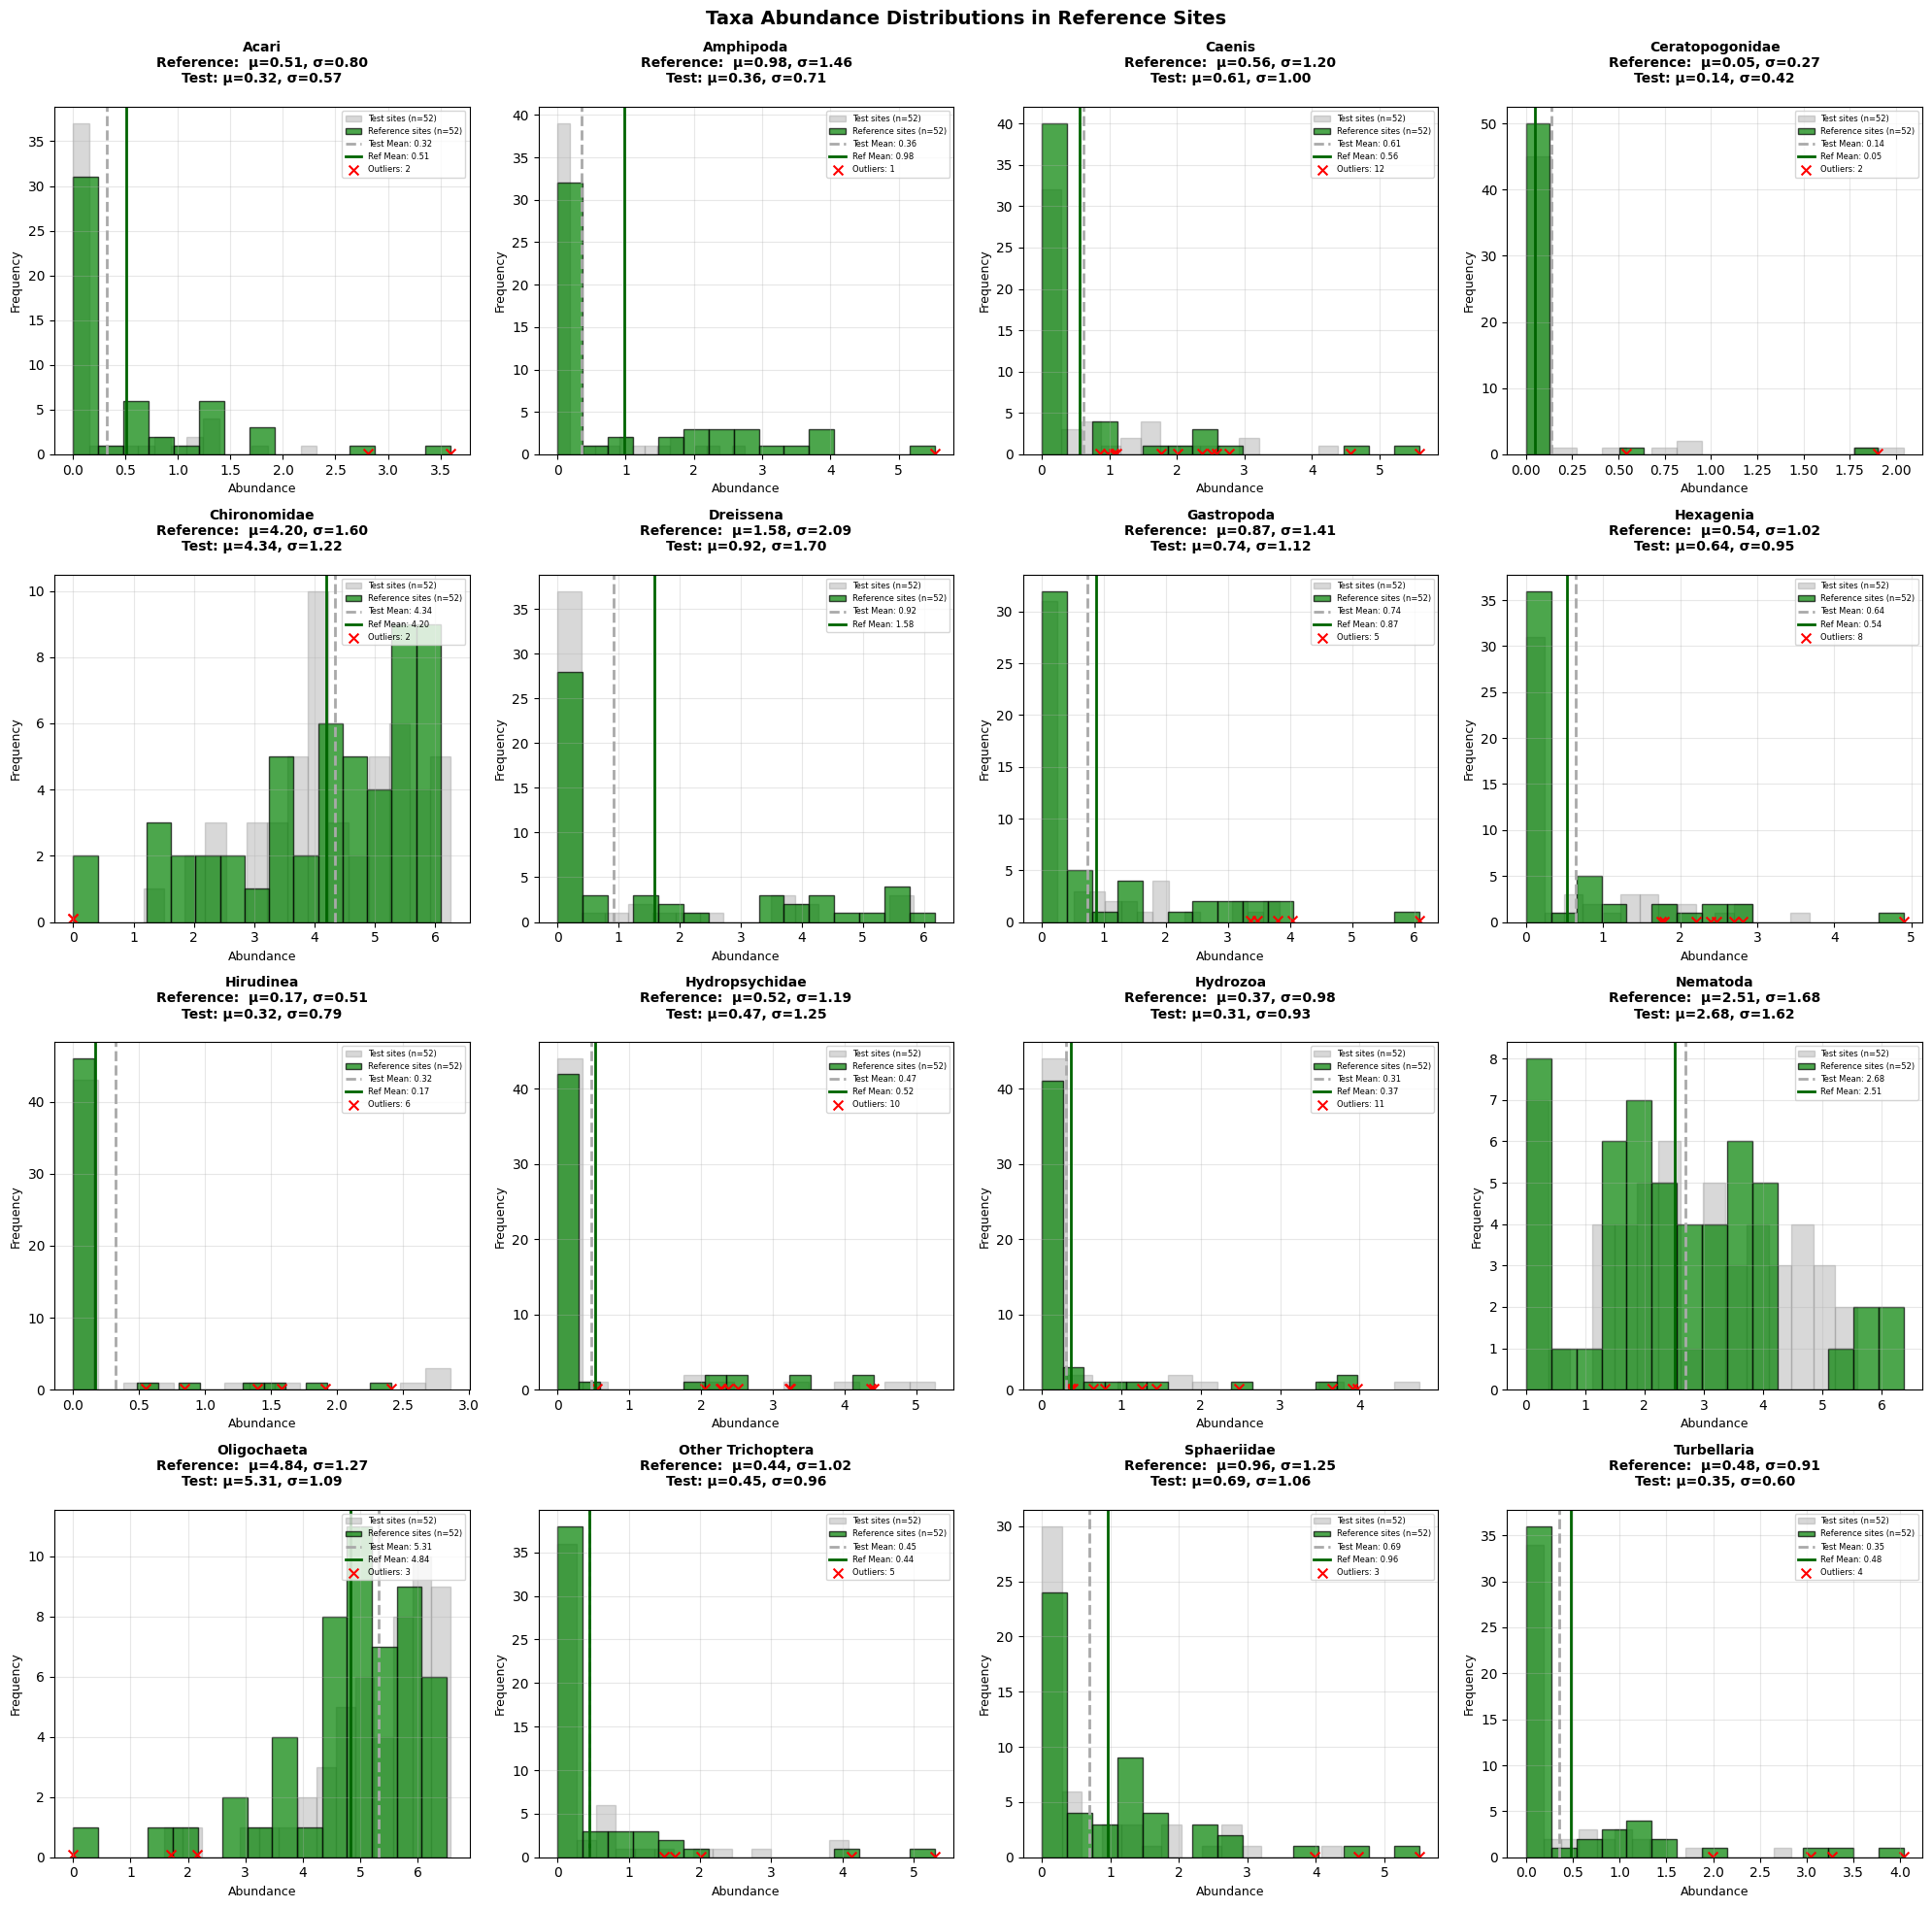

In [9]:
# check the histogram (with simple statistics) of the species data in references vs test sites
n_taxa = len(taxa_features)
n_cols = 4
n_rows = (n_taxa + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

# Get non-reference sites for background
non_ref_indices = taxa_all.index.difference(taxa_ref.index)
taxa_non_ref = taxa_all.loc[non_ref_indices]

for i, taxon in enumerate(taxa_features):
    ax = axes[i]
    
    # Get data for this taxon
    taxon_ref = taxa_ref[taxon].dropna()
    taxon_non_ref = taxa_non_ref[taxon].dropna()
    
    # Calculate statistics for reference sites
    mean_val = taxon_ref.mean()
    std_val = taxon_ref.std()
    q1 = taxon_ref.quantile(0.25)
    q3 = taxon_ref.quantile(0.75)
    iqr = q3 - q1
    
    # Calculate statistics for non-reference (test) sites
    non_ref_mean = taxon_non_ref.mean()
    non_ref_std = taxon_non_ref.std()
    
    # Identify outliers using 1.5 IQR rule
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = taxon_ref[(taxon_ref < lower_bound) | (taxon_ref > upper_bound)]
    
    # Create histogram - non-reference sites as background (gray, transparent)
    ax.hist(taxon_non_ref, bins=15, alpha=0.3, color='gray', edgecolor='gray',
            label=f'Test sites (n={len(taxon_non_ref)})')
    
    # Create histogram - reference sites in front (green)
    ax.hist(taxon_ref, bins=15, alpha=0.7, color='green', edgecolor='black',
            label=f'Reference sites (n={len(taxon_ref)})')
    
    # Add vertical line for non-reference mean
    ax.axvline(non_ref_mean, color='darkgray', linestyle='--', linewidth=2,
               label=f'Test Mean: {non_ref_mean:.2f}')
    
    # Add vertical line for reference mean
    ax.axvline(mean_val, color='darkgreen', linestyle='-', linewidth=2,
               label=f'Ref Mean: {mean_val:.2f}')
    
    # Add outlier markers if any exist
    if len(outliers) > 0:
        ax.scatter(outliers, [0.1] * len(outliers), color='red', s=50,
                   marker='x', label=f'Outliers: {len(outliers)}')
    
    # Add statistics text with both reference and test site summaries
    stats_text = (f'Reference:  μ={mean_val:.2f}, σ={std_val:.2f}\n'
                  f'Test: μ={non_ref_mean:.2f}, σ={non_ref_std:.2f}\n')

    # Styling
    ax.set_title(f'{taxon}\n{stats_text}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Abundance', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=6, loc='upper right')
    ax.grid(True, alpha=0.3)

# Hide empty subplots
for i in range(n_taxa, len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Taxa Abundance Distributions in Reference Sites',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

The individual taxa abundances are not significantly different across pollution levels (reference vs test sites), as shown in the figure above.

**However,** according to Legendre & Legendre, **pollution impacts multivariate community composition**, not the univariate abundance of individual taxa.

What acutally changes include:
- Relative abundances across taxa (community composition)
- Multivariate structure of the assemblages (species diversity)
- Presence-absence of sensitive vs tolerant taxa

## Asymmetrical Association Measures on sites of species data (address double-zero problem)

According to the book *"Numerical Ecology with R"* by Legendre and Legendre (2019),
the **presence** of a taxon often has a clearer interpretation than its **absence**.
The shared absence at two sites does not contribute to similarity between them, and it raises the so-called **"double-zero problem"**.

Dissimilarity measures made on raw abundance ignores this issue and can lead to ecologically meaningless results.
To address this issue, several transformations (and their corresponding dissimilarity measures) have been proposed: **Bray-Curtis, Chord, Hellinger, Chi-square**.

Take these transformations on species data and the dissimilarity matrix built upon them can effectively solve the double-zero problem.

### Chord normalization

the chord-normalized relative abundance of taxon \(j\) at site \(i\) is:
    
$$
c_{ij} = \frac{p_{ij}}{\sqrt{\sum_{j=1}^{m} p_{ij}^2}}, \quad j = 1, \dots, m
$$

Each site \(i\) is represented as a column vector in the m-dimensional taxa space:

$$
\mathbf{c}_i = \begin{pmatrix} c_{i1} \\ c_{i2} \\ \vdots \\ c_{im} \end{pmatrix}
$$

where the norm of each vector equals 1:

$$
\|\mathbf{c}_i\| = \sqrt{\sum_{j=1}^{m} c_{ij}^2} = 1, \quad i = 1, \dots, n
$$

This places all sites on the unit hypersphere in the m-dimensional taxa space, where Euclidean distances between sites are determined by composition differences (direction) only.

In [10]:
# define the chord transformation computation function
def chord_transform(df):
    """Apply chord transformation to taxa data of each site."""
    # Calculate the norm of each site's taxa vector (row-wise)
    norm_rows = np.sqrt((df ** 2).sum(axis = 1))
    # Divide each taxa value by the site's norm 
    chord_df = df.div(norm_rows, axis=0)
    return chord_df

# Apply chord transformation to reference and non-reference taxa data
taxa_ref_chord = chord_transform(taxa_ref)
taxa_non_ref_chord = chord_transform(taxa_non_ref)

Compute the distance matrix on chord-normalized data using Euclidean distance, which is called the **Chord distance matrix**.

In [11]:
# compute the chord distance matrix among reference sites
from sklearn.metrics import pairwise_distances

# Using Euclidean distance on chord-transformed data gives us the chord distance
chord_distance_matrix = pairwise_distances(taxa_ref_chord, metric='euclidean')

# Convert to DataFrame for better visualization with site IDs as labels
chord_distance_df = pd.DataFrame(chord_distance_matrix, 
                                index=taxa_ref_chord.index, 
                                columns=taxa_ref_chord.index)

print("Chord Distance Matrix (Reference Sites):")
print(f"Shape: {chord_distance_df.shape}")
print(f"Distance range: {chord_distance_df.values[chord_distance_df.values > 0].min():.4f} to {chord_distance_df.values.max():.4f}")
print("\nFirst 5x5 subset:")
print(chord_distance_df.iloc[:5, :5].round(4))

Chord Distance Matrix (Reference Sites):
Shape: (52, 52)
Distance range: 0.1135 to 1.3595

First 5x5 subset:
StationID     S54     S70     S96     S72     S65
StationID                                        
S54        0.0000  0.9340  1.0105  0.6315  0.9748
S70        0.9340  0.0000  0.4669  0.5790  0.7216
S96        1.0105  0.4669  0.0000  0.6788  0.5083
S72        0.6315  0.5790  0.6788  0.0000  0.8313
S65        0.9748  0.7216  0.5083  0.8313  0.0000


### Hellinger normalization

Hellinger normalization is similar to chord normalization, but it takes the square root of each chord-transformed value, which gives higher weight to abundant taxa and less weight to rare taxa.

In [12]:
# define the hellinger transformation computation function
def hellinger_transform(df):
    """Apply Hellinger transformation to taxa data of each site."""
    # First, calculate relative abundances (same as chord transformation start)
    norm_rows = np.sqrt((df **2).sum(axis = 1))
    chord_df = df.div(norm_rows, axis=0)
    
    # Then take square root of relative abundances
    hellinger_df = np.sqrt(chord_df)
    
    return hellinger_df

# Apply Hellinger transformation to reference and non-reference taxa data
taxa_ref_hellinger = hellinger_transform(taxa_ref)
taxa_non_ref_hellinger = hellinger_transform(taxa_non_ref)

Compute the distance matrix on hellinger-normalized data using Euclidean distance, which is called the **Hellinger distance matrix**.

In [13]:
# compute the hellinger distance matrix among reference sites
hellinger_distance_matrix = pairwise_distances(taxa_ref_hellinger, metric='euclidean')

# Convert to DataFrame for better visualization with site IDs as labels
hellinger_distance_df = pd.DataFrame(hellinger_distance_matrix, 
                                    index=taxa_ref_hellinger.index, 
                                    columns=taxa_ref_hellinger.index)

print("Hellinger Distance Matrix (Reference Sites):")
print(f"Shape: {hellinger_distance_df.shape}")
print(f"Distance range: {hellinger_distance_df.values[hellinger_distance_df.values > 0].min():.4f} to {hellinger_distance_df.values.max():.4f}")
print("\nFirst 5x5 subset:")
print(hellinger_distance_df.iloc[:5, :5].round(4))

Hellinger Distance Matrix (Reference Sites):
Shape: (52, 52)
Distance range: 0.0722 to 1.8435

First 5x5 subset:
StationID     S54     S70     S96     S72     S65
StationID                                        
S54        0.0000  1.3602  1.4777  1.0995  1.4444
S70        1.3602  0.0000  1.0053  0.8314  1.2063
S96        1.4777  1.0053  0.0000  0.9821  0.7875
S72        1.0995  0.8314  0.9821  0.0000  1.1479
S65        1.4444  1.2063  0.7875  1.1479  0.0000


## Preview: Hierarchical Clustering on Asymmetrical Association Measures

After applying some "double-zero problem" addressing transformations and computing the corresponding dissimilarity matrices (association measures),
we can feed the dissimilarity matrices into hierarchical clustering algorithms to identify taxa composition patterns across reference sites.

A variety of linkage methods can be used, including single, complete, average, and ward linkage.

Here we choose **ward** linkage to do **Ward's hierarchical clustering**, because its computation try to minimize the total within-cluster variance at each
merge step, leading to more compact clusters. Additionally, it's **similar to ANOVA analysis** that computes within-group variances and provides a statistical framework for assessing cluster validity.

Try the clustering on chord distance matrix first.

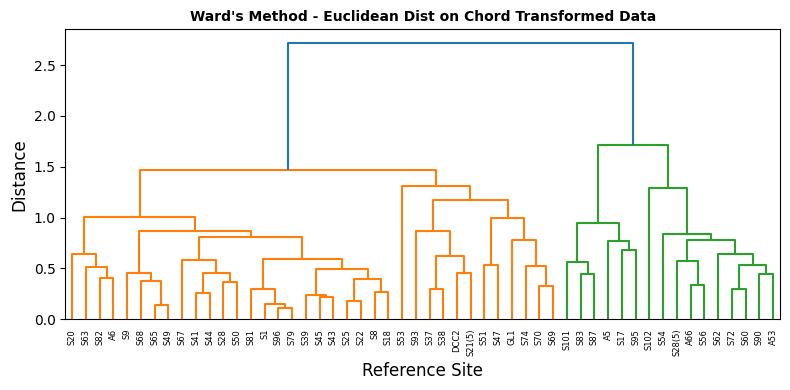

In [14]:
# make Ward's clustering based on the chord transformed data
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# perform hierarchical clustering using Ward's method
linkage_matrix = linkage(taxa_ref_chord, method='ward')

# Plot the dendrogram
plt.figure(figsize=(8, 4))
dendrogram(linkage_matrix, labels=taxa_ref_chord.index, leaf_rotation=90)
plt.title("Ward's Method - Euclidean Dist on Chord Transformed Data", fontsize=10, fontweight='bold')
plt.xlabel("Reference Site", fontsize=12)
plt.ylabel("Distance", fontsize=12)
plt.tight_layout()
plt.show()

Now try the clustering on hellinger distance matrix.

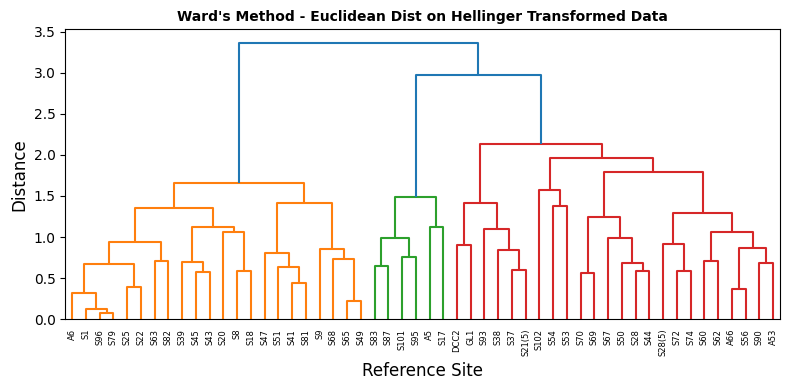

In [15]:
# make Ward's clustering based on the hellinger transformed data
linkage_matrix = linkage(taxa_ref_hellinger, method='ward')

# Plot the dendrogram
plt.figure(figsize=(8, 4))
dendrogram(linkage_matrix, labels=taxa_ref_hellinger.index, leaf_rotation=90)
plt.title("Ward's Method - Euclidean Dist on Hellinger Transformed Data", fontsize=10, fontweight='bold')
plt.xlabel("Reference Site", fontsize=12)
plt.ylabel("Distance", fontsize=12)
plt.tight_layout()
plt.show()

### Check the spatial and env-feature conditions

Skip the validation of clustering results at the preview stage, subjectively chose k groups as a good typology for some external comparisons

- spatial distribution 
- differences in environmental features

In [16]:
# apply hierarchical clustering with k clusters using a specified distance matrix
from sklearn.cluster import AgglomerativeClustering

preview_k = 4  # number of clusters
preview_linkage = 'ward'
preview_dis_matrix = chord_distance_matrix # a computed distance matrix
preview_tran_data = taxa_ref_hellinger # for ward's clusteirng
# feed them into clustering function
clustering = AgglomerativeClustering(n_clusters=preview_k, linkage=preview_linkage)
cluster_labels = clustering.fit_predict(preview_tran_data)

# Create a DataFrame to map sites to their cluster groups
site_clusters = pd.DataFrame({
    'StationID': taxa_ref_hellinger.index,
    'Cluster_Group': cluster_labels
})

# add the cluster group labels as a subblock to the reference data
reference_data[('Cluster_Group', "asym", "hellinger_groups")] = site_clusters.set_index('StationID').loc[reference_data.index, 'Cluster_Group']
# add the cluster group labels as a subblock to the raw reference data
raw_reference_data["hellinger_groups"] = site_clusters.set_index('StationID').loc[raw_reference_data.index, 'Cluster_Group']

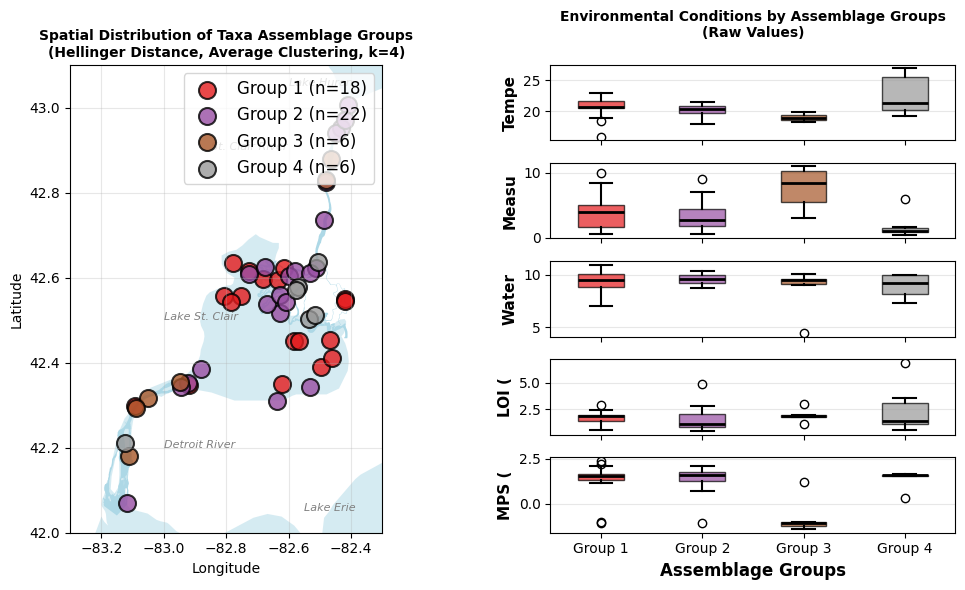

Assemblage Groups Analysis Summary:

Assemblage Groups Summary Table:
Group    N   Sites                     Waterbodies                    Top 3 Dominant Taxa                               
------------------------------------------------------------------------------------------------------------------------
Group 1  18  S54, S70, S72, S74, S5... LSC(16); DR(2)                 Oligochaeta(0.687); Nematoda(0.602); Chironomid...
Group 2  22  S96, S65, S51, S41, S8... LSC(13); SCR(6); DR(3)         Oligochaeta(0.811); Chironomidae(0.756); Nemato...
Group 3  6   A5, S17, S101, S83, S8... DR(4); SCR(2)                  Dreissena(0.699); Oligochaeta(0.614); Hydropsyc...
Group 4  6   DCC2, GL1, S93, S37, S... LSC(5); DR(1)                  Chironomidae(0.737); Oligochaeta(0.674); Caenis...

Environmental Conditions Summary (Mean ± Std):
Group     Temperature    Measured Dep   Water DO Bot   LOI            MPS            
----------------------------------------------------------------------

In [17]:
# visualize the boxplots for the environmental features across the selected groups
fig = plt.figure(figsize=(10, 6))

# Create subplot layout: left panel for map (1/2 width), right panel split into 5 rows for each env variable
ax_map = plt.subplot2grid((5, 2), (0, 0), rowspan=5)  # Map spans full left side

# Left panel: Spatial distribution map
plot_rivers_lakes(ax=ax_map, annotating=True)

colors = plt.cm.Set1(np.linspace(0, 1, preview_k))
cluster_names = [f'Group {i+1}' for i in range(preview_k)]

for cluster_id in range(preview_k):
    cluster_sites = raw_reference_data[raw_reference_data['hellinger_groups'] == cluster_id]
    
    ax_map.scatter(cluster_sites['Longitude'], cluster_sites['Latitude'], 
               c=[colors[cluster_id]], s=150, alpha=0.8, 
               edgecolors='black', linewidths=1.5,
               label=f'{cluster_names[cluster_id]} (n={len(cluster_sites)})')

ax_map.set_title(f'Spatial Distribution of Taxa Assemblage Groups\n(Hellinger Distance, Average Clustering, k={preview_k})', 
             fontsize=10, fontweight='bold')
ax_map.legend(loc='upper right', fontsize=12)
ax_map.grid(True, alpha=0.3)

# Right panel: Environmental variables boxplots (5 separate axes for each variable)
env_features_selected = ['Temperature (oC)', 'Measured Depth (m)', 'Water DO Bottom (mg/L)', 
                        'LOI (%)', 'MPS (Phi)']

# Create 5 subplots on the right side (one for each environmental feature)
env_axes = []
for i in range(5):
    ax_env = plt.subplot2grid((5, 2), (i, 1))
    env_axes.append(ax_env)

# Prepare data for boxplots
for idx, (ax_env, feature) in enumerate(zip(env_axes, env_features_selected)):
    # Collect data for each group
    data_by_group = []
    for cluster_id in range(preview_k):
        cluster_indices = raw_reference_data[raw_reference_data['hellinger_groups'] == cluster_id].index
        group_data = raw_reference_data.loc[cluster_indices, feature].dropna()
        data_by_group.append(group_data)
    
    # Create boxplot
    bp = ax_env.boxplot(data_by_group, tick_labels=cluster_names, patch_artist=True,
                        boxprops=dict(alpha=0.7),
                        medianprops=dict(color='black', linewidth=2),
                        whiskerprops=dict(linewidth=1.5),
                        capprops=dict(linewidth=1.5))
    
    # Color the boxes according to cluster colors
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Styling
    ax_env.set_ylabel(feature[:5], fontsize=11, fontweight='bold')
    ax_env.grid(True, alpha=0.3, axis='y')
    ax_env.tick_params(axis='x', labelsize=10)
    ax_env.tick_params(axis='y', labelsize=10)
    
    # Only show x-label on bottom plot
    if idx == len(env_features_selected) - 1:
        ax_env.set_xlabel('Assemblage Groups', fontsize=12, fontweight='bold')
    else:
        ax_env.set_xticklabels([])

# Add overall title for right panel
env_axes[0].set_title('Environmental Conditions by Assemblage Groups\n(Raw Values)', 
                     fontsize=10, fontweight='bold', pad=20)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

# Print summary statistics
print("Assemblage Groups Analysis Summary:")
print("=" * 50)
# Collect taxa data for summary
group_means_taxa = []
for cluster_id in range(preview_k):
    cluster_indices = raw_reference_data[raw_reference_data['hellinger_groups'] == cluster_id].index
    group_taxa_data = taxa_ref_hellinger.loc[cluster_indices]
    group_mean = group_taxa_data.mean()
    group_means_taxa.append(group_mean)

# Create summary table
summary_data = []
for cluster_id in range(preview_k):
    cluster_sites = raw_reference_data[raw_reference_data['hellinger_groups'] == cluster_id]
    
    # Basic group info
    group_info = {
        'Group': cluster_names[cluster_id],
        'Sites_Count': len(cluster_sites),
        'Sites': ', '.join(map(str, cluster_sites.index.tolist())),
        'Waterbodies': '; '.join([f"{wb}({count})" for wb, count in cluster_sites['Waterbody'].value_counts().items()])
    }
    
    # Top 3 dominant taxa
    cluster_taxa_means = group_means_taxa[cluster_id].sort_values(ascending=False)
    top_taxa = cluster_taxa_means.head(3)
    group_info['Top_3_Taxa'] = '; '.join([f"{taxa}({val:.3f})" for taxa, val in top_taxa.items()])
    
    # Environmental conditions
    for feature in env_features_selected:
        feature_data = cluster_sites[feature].dropna()
        group_info[f'{feature}_Mean'] = feature_data.mean()
        group_info[f'{feature}_Std'] = feature_data.std()
    
    summary_data.append(group_info)

# Convert to DataFrame for better display
summary_df = pd.DataFrame(summary_data)

print("\nAssemblage Groups Summary Table:")
print("=" * 120)
print(f"{'Group':<8} {'N':<3} {'Sites':<25} {'Waterbodies':<30} {'Top 3 Dominant Taxa':<50}")
print("-" * 120)

for _, row in summary_df.iterrows():
    sites_short = row['Sites'][:22] + "..." if len(row['Sites']) > 25 else row['Sites']
    wb_short = row['Waterbodies'][:27] + "..." if len(row['Waterbodies']) > 30 else row['Waterbodies']
    taxa_short = row['Top_3_Taxa'][:47] + "..." if len(row['Top_3_Taxa']) > 50 else row['Top_3_Taxa']
    
    print(f"{row['Group']:<8} {row['Sites_Count']:<3} {sites_short:<25} {wb_short:<30} {taxa_short:<50}")

print("\nEnvironmental Conditions Summary (Mean ± Std):")
print("=" * 120)
env_header = f"{'Group':<10}"
for feature in env_features_selected:
    short_name = feature.split('(')[0].strip()[:12]
    env_header += f"{short_name:<15}"
print(env_header)
print("-" * 120)

for _, row in summary_df.iterrows():
    env_line = f"{row['Group']:<10}"
    for feature in env_features_selected:
        mean_val = row[f'{feature}_Mean']
        std_val = row[f'{feature}_Std']
        env_line += f"{mean_val:.2f}±{std_val:.2f}"[:14].ljust(15)
    print(env_line)

## Deciding a Good Typology for Hierarchical Clustering Results

Typology refers to a bunch of decisions/results that derive from hierarchical clustering analysis on the taxa data.

A good typology should have **a well representative (retains dissimilarity structure) cutting level** and
**good ecological interpretability**, both built upon a **meaningful clustering algorithm and dissimilarity measure**.

### Three aspects of specific computation to decide a good typology. 

**1. Choose dissimilarity measure and clustering algorithm**
- The dissimilarity measure (Bray–Curtis, Hellinger–Euclidean, Chord)
- The clustering algorithm (hierarchical)
- The linkage method: single, complete, average, ward
- Method:
  - (a) cophenetic correlation analysis

**2. Choose a cut level (Internal validation)**
- How many groups want to be formed
- How good the cut level retains the original dissimilarity structure
  - (a) fusion-level plots


**3. Provide an ecological interpretation (External validation)**
- Define what those clusters mean in various real ecological interpretations.
- Connects the clusters with ecological interpretation with:
  - (a) species composition
  - (b) the habitat conditions; 
  - (c) environmental processes

### Choose the dissimilarity measure and clustering algorithm

- **Dissimilarity measure: Hellinger distance**

    Backed up by the book and limited evidence, we choose **Hellinger distance** as the asymmetrical association measure to enter the later hierarchical clustering analysis.

- **Clustering algorithm: Hierarchical clustering with Ward's linkage**

    Based on the Hellinger distance matrix, apply hierarchcal clustering with 4 linkage methods: single, complete, average, ward.

    Use cophenetic correlation analysis to check which one retains the original dissimilarity structure best.

    <span style="color:blue">However, Ward's linkage is favored here disregarding the cophenetic correlation</span>
    because Ward's method provides a more balanced cluster sizes that we can train **Linear Discriminant Analysis (LDA)** models on.

    <span style="color:blue">This unimpeded choice of Ward's linkage may change with more data set coming later.</span>

Cophenetic correlation analysis for 4 linkages with Hellinger distance matrix

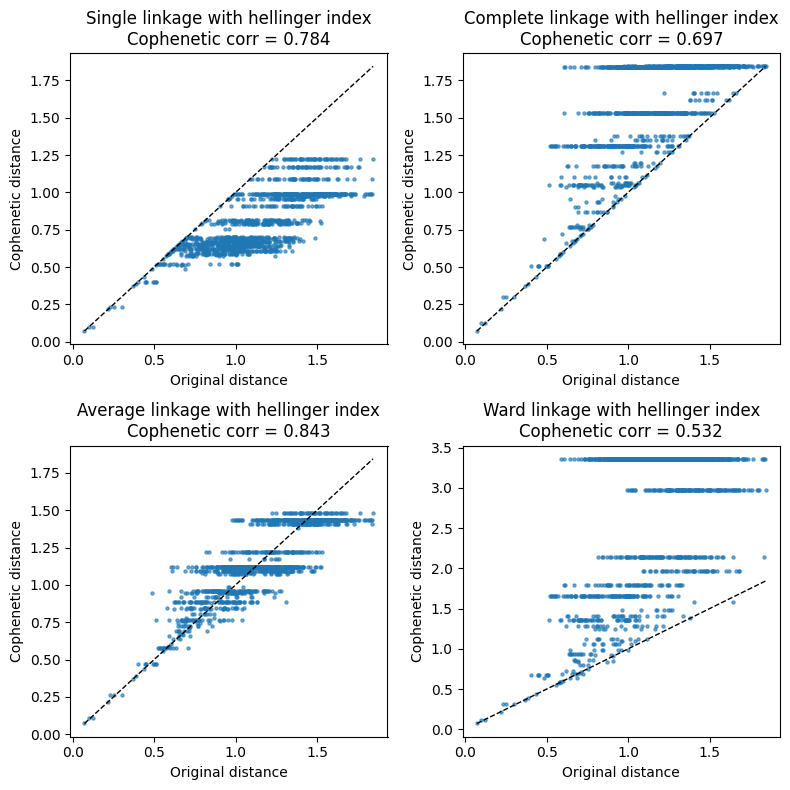

In [18]:
# try the Cophenetic Correlation to compare different linkage methods
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, cophenet
import matplotlib.pyplot as plt

# Compute condensed distance matrix directly from transformed data
# This is more reliable than converting from square form
D_condensed = pdist(taxa_ref_hellinger, metric='euclidean')

methods = ["single", "complete", "average", "ward"]
coph_corrs = {}

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
axs = axs.ravel()

for ax, method in zip(axs, methods):
    # seperate the feeded data for ward's method
    if method == "ward":
        Z = linkage(taxa_ref_hellinger, method=method)
    else:
        Z = linkage(D_condensed, method=method)
    coph_corr, coph_dists = cophenet(Z, D_condensed)  # Note: returns (correlation, cophenetic distances)
    coph_corrs[method] = coph_corr

    ax.scatter(D_condensed, coph_dists, s=5, alpha=0.6)
    ax.plot([D_condensed.min(), D_condensed.max()], [D_condensed.min(), D_condensed.max()], "k--", linewidth=1)
    ax.set_title(f"{method.capitalize()} linkage with hellinger index\n"
                 f"Cophenetic corr = {coph_corr:.3f}")
    ax.set_xlabel("Original distance")
    ax.set_ylabel("Cophenetic distance")

plt.tight_layout()
plt.show()

### Choose a cut level (Internal validation)

Use fusion-level plots to visualize how clusters are formed at each merge step and decide a good cutting level.

Fusion-level plots for 4 linkages with Hellinger distance matrix. 

Each fusion-level plot is read from top left to bottom right.
A node shows the group number at each merge step (x-axis: fusion height; y-axis: group number),
the **segment/plateau** to its right indicates the linkage distance used to merge two clusters at that step.

To read a fusion-level plot:

**The longer the plateau $\rightarrow$ the longer distant the two clusters to be merged $\rightarrow$ the more distinct/stable the current clusters are $\rightarrow$ the better the cut level is**

Therefore, listing wanted numbers of clusters and checking their fusion heights (node heights/linkage distances) can help decide a good cut level (specific number of clusters).

In [19]:
# define the fusion plot function as R in the book
def fusion_plot(Z, method_name, distance_name="Chord"):
    """
    Plot fusion levels as a step plot showing how many clusters remain at each node height.
    
    Parameters:
    -----------
    Z : ndarray
        Linkage matrix from hierarchical clustering
    method_name : str
        Name of the linkage method (e.g., 'complete', 'ward')
    distance_name : str
        Name of the distance measure (e.g., 'Chord', 'Hellinger')
    """
    n = Z.shape[0] + 1  # number of original observations
    heights = Z[:, 2]   # fusion heights
    
    # k goes from n down to 1 as we merge clusters
    k_vals = np.arange(n, 0, -1)
    
    # Create extended arrays for step plot
    # Start with n clusters at height 0, then decrease as we merge
    h_extended = np.concatenate([[0], heights])
    k_extended = k_vals
    
    # Plot as step function (post style keeps horizontal line then drops)
    plt.step(h_extended, k_extended, where='post', linewidth=1.5, color='red')
    
    # Add markers at fusion points
    plt.plot(heights, k_vals[1:], 'o', markersize=4, color='red', alpha=0.7)
    
    # Add text labels for selected k values
    label_positions = [n, n//2, n//4, 5, 3, 2]
    for k in label_positions:
        if k <= n and k >= 1:
            idx = n - k
            if idx < len(heights):
                h = heights[idx] if idx > 0 else 0
                plt.text(h, k, str(k), fontsize=8, ha='left', va='center', 
                        color='red', fontweight='normal')
    
    plt.xlabel("h (node height)", fontsize=10)
    plt.ylabel("k (number of clusters)", fontsize=10)
    plt.title(f"Fusion levels - {distance_name} - {method_name.capitalize()}", 
             fontsize=11, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Highlight ward method with yellow background if applicable
    if method_name.lower() == 'ward':
        plt.gca().set_facecolor('#ffffcc')

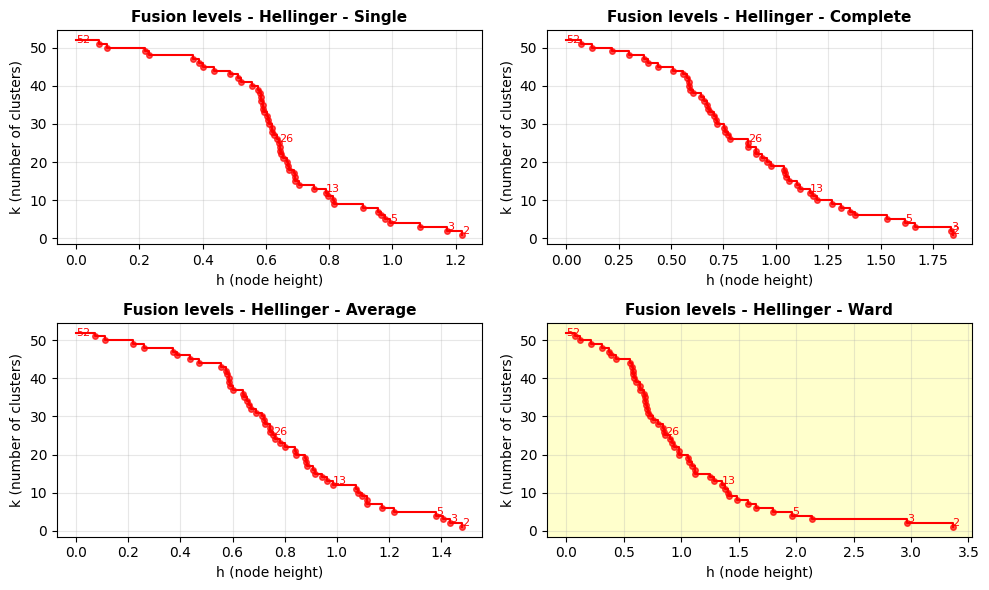

In [20]:
# plot the fusion levels for the four linkage functions
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
axs = axs.ravel()

for ax, method in zip(axs, methods):
    plt.sca(ax)
    Z = linkage(taxa_ref_hellinger, method=method)
    fusion_plot(Z, method, distance_name="Hellinger")

plt.tight_layout()
plt.show()

### Provide an ecological interpretation (External validation)

This is the final step to decide a typology: consider the ecological interpretability of the groups.

From another point of view, the clusters obtained from the community composition data can be considered as a factor, or classification criterion, in the ANOVA sense **(Numerical Ecology with R, Legendre & Legendre, 2019)**. 

Under this view, it is good **to perform assessments of ANOVA assumptions** on the habitat features across the clusters and **apply ANOVA if assumptions are met**.

In the ecological interpretation, despite the clustering results act as explanatory factors in the ANOVA, ecologically speaking we really look for an **environmental interpretation of the groups** of sites **(Numerical Ecology with R, Legendre & Legendre, 2019)**, **it validates clusters statistically - not how ecological processes truly work.**

(Confronting the clustering results (considering as response data) with external, independent explanatory data could be done by discriminant analysis(Numerical Ecology with R, Legendre & Legendre, 2019).)

#### Check the ANOVA assumptions across the groups

Given the chosen 4 groups from Ward's hierarchical clustering on Hellinger distance matrix, check the ANOVA assumptions on the habitat features across the groups.

To a habitat feature $x$, it should meet the following assumptions of its uncertainty across (factor) levels:

- **Normality of residuals**: environmental variable values in each cluster should be roughly normal
  
- **Homogeneity of variance (homoscedasticity)**: groups should have similar variances
  
- **Independence**: observations (sites) should be independent

In [21]:
# Assessment of ANOVA assumptions across habitat features and cluster groups
from scipy import stats
from scipy.stats import levene, shapiro, anderson

# Select environmental features for ANOVA assumption testing
env_features_anova = ['Temperature (oC)', 'Measured Depth (m)', 'Water DO Bottom (mg/L)', 
                      'LOI (%)', 'MPS (Phi)']

# Get the cluster groups from previous analysis (using k=4 Ward's clustering on Hellinger)
cluster_groups = raw_reference_data['hellinger_groups']
n_groups = preview_k

# Store results for summary
assumption_results = []

for feature in env_features_anova:
    # Get data by group
    groups_data = []
    for group_id in range(n_groups):
        group_values = raw_reference_data[raw_reference_data['hellinger_groups'] == group_id][feature].dropna()
        groups_data.append(group_values)
    
    # Overall data
    all_values = raw_reference_data[feature].dropna()
    
    # Fit ANOVA model to get residuals
    group_means = [group.mean() for group in groups_data]
    residuals = []
    
    for group_id, group_data in enumerate(groups_data):
        group_residuals = group_data - group_means[group_id]
        residuals.extend(group_residuals)
    
    residuals = np.array(residuals)
    
    # Shapiro-Wilk test on residuals
    if len(residuals) >= 3:
        shapiro_stat, shapiro_p = shapiro(residuals)
        normality_pass = shapiro_p > 0.05
    else:
        shapiro_stat, shapiro_p = np.nan, np.nan
        normality_pass = False
    
    # Anderson-Darling test on residuals
    anderson_result = anderson(residuals, dist='norm')
    
    # Check normality for each group
    group_normality = []
    for group_id, group_data in enumerate(groups_data):
        if len(group_data) >= 3:
            sw_stat, sw_p = shapiro(group_data)
            group_normality.append(sw_p > 0.05)
            status = "✓" if sw_p > 0.05 else "✗"
        else:
            group_normality.append(False)
    
    # ========================================
    # 2. HOMOGENEITY OF VARIANCE (Levene's test)
    # ========================================
    # Levene's test
    levene_stat, levene_p = levene(*groups_data)
    if levene_p > 0.05:
        variance_pass = True
    else:
        variance_pass = False
    
    # Store results
    assumption_results.append({
        'Feature': feature,
        'Shapiro_W': shapiro_stat,
        'Shapiro_p': shapiro_p,
        'Normality_Pass': normality_pass,
        'Levene_Stat': levene_stat,
        'Levene_p': levene_p,
        'Variance_Pass': variance_pass,
        'All_Assumptions_Pass': normality_pass and variance_pass
    })
    
# Create compact table output for results
results_df = pd.DataFrame(assumption_results)

# Table 1: Test Statistics
print("\n┌─ ANOVA Assumption Test Statistics (Raw Habitat Features) ─" + "─" * 60 + "┐")
print("│")
print("│  Feature                     │  Shapiro-W │  Shapiro-p │  Levene   │  Levene-p │  Pass  │")
print("│" + "─" * 30 + "┼" + "─" * 12 + "┼" + "─" * 12 + "┼" + "─" * 11 + "┼" + "─" * 11 + "┼" + "─" * 8 + "│")

for _, row in results_df.iterrows():
    feature_short = row['Feature'][:27] + '...' if len(row['Feature']) > 27 else row['Feature']
    pass_mark = "✓" if row['All_Assumptions_Pass'] else "✗"
    print(f"│  {feature_short:<28} │  {row['Shapiro_W']:>8.4f}  │  {row['Shapiro_p']:>8.4f}  │  {row['Levene_Stat']:>7.4f}  │  {row['Levene_p']:>7.4f}  │  {pass_mark:^6} │")

print("│")
print("└" + "─" * 118 + "┘")

# Table 2: Summary Statistics
n_pass_normality = results_df['Normality_Pass'].sum()
n_pass_homogeneity = results_df['Variance_Pass'].sum()
n_pass_overall = results_df['All_Assumptions_Pass'].sum()
n_total = len(results_df)

print("\n┌─ Summary of Assumption Test Results ─┐")
print("│")
print(f"│  Normality passed:     {n_pass_normality}/{n_total}            │")
print(f"│  Homogeneity passed:   {n_pass_homogeneity}/{n_total}            │")
print(f"│  All assumptions met:  {n_pass_overall}/{n_total}            │")
print("│")
print("└" + "─" * 39 + "┘")



┌─ ANOVA Assumption Test Statistics (Raw Habitat Features) ─────────────────────────────────────────────────────────────┐
│
│  Feature                     │  Shapiro-W │  Shapiro-p │  Levene   │  Levene-p │  Pass  │
│──────────────────────────────┼────────────┼────────────┼───────────┼───────────┼────────│
│  Temperature (oC)             │    0.9409  │    0.0122  │   5.4612  │   0.0026  │    ✗    │
│  Measured Depth (m)           │    0.9678  │    0.1702  │   1.2282  │   0.3097  │    ✓    │
│  Water DO Bottom (mg/L)       │    0.8584  │    0.0000  │   1.8495  │   0.1508  │    ✗    │
│  LOI (%)                      │    0.8658  │    0.0000  │   2.2295  │   0.0968  │    ✗    │
│  MPS (Phi)                    │    0.8050  │    0.0000  │   0.2472  │   0.8629  │    ✗    │
│
└──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─ Summary of Assumption Test Results ─┐
│
│  Normality passed:     1/5            │
│  Homogenei

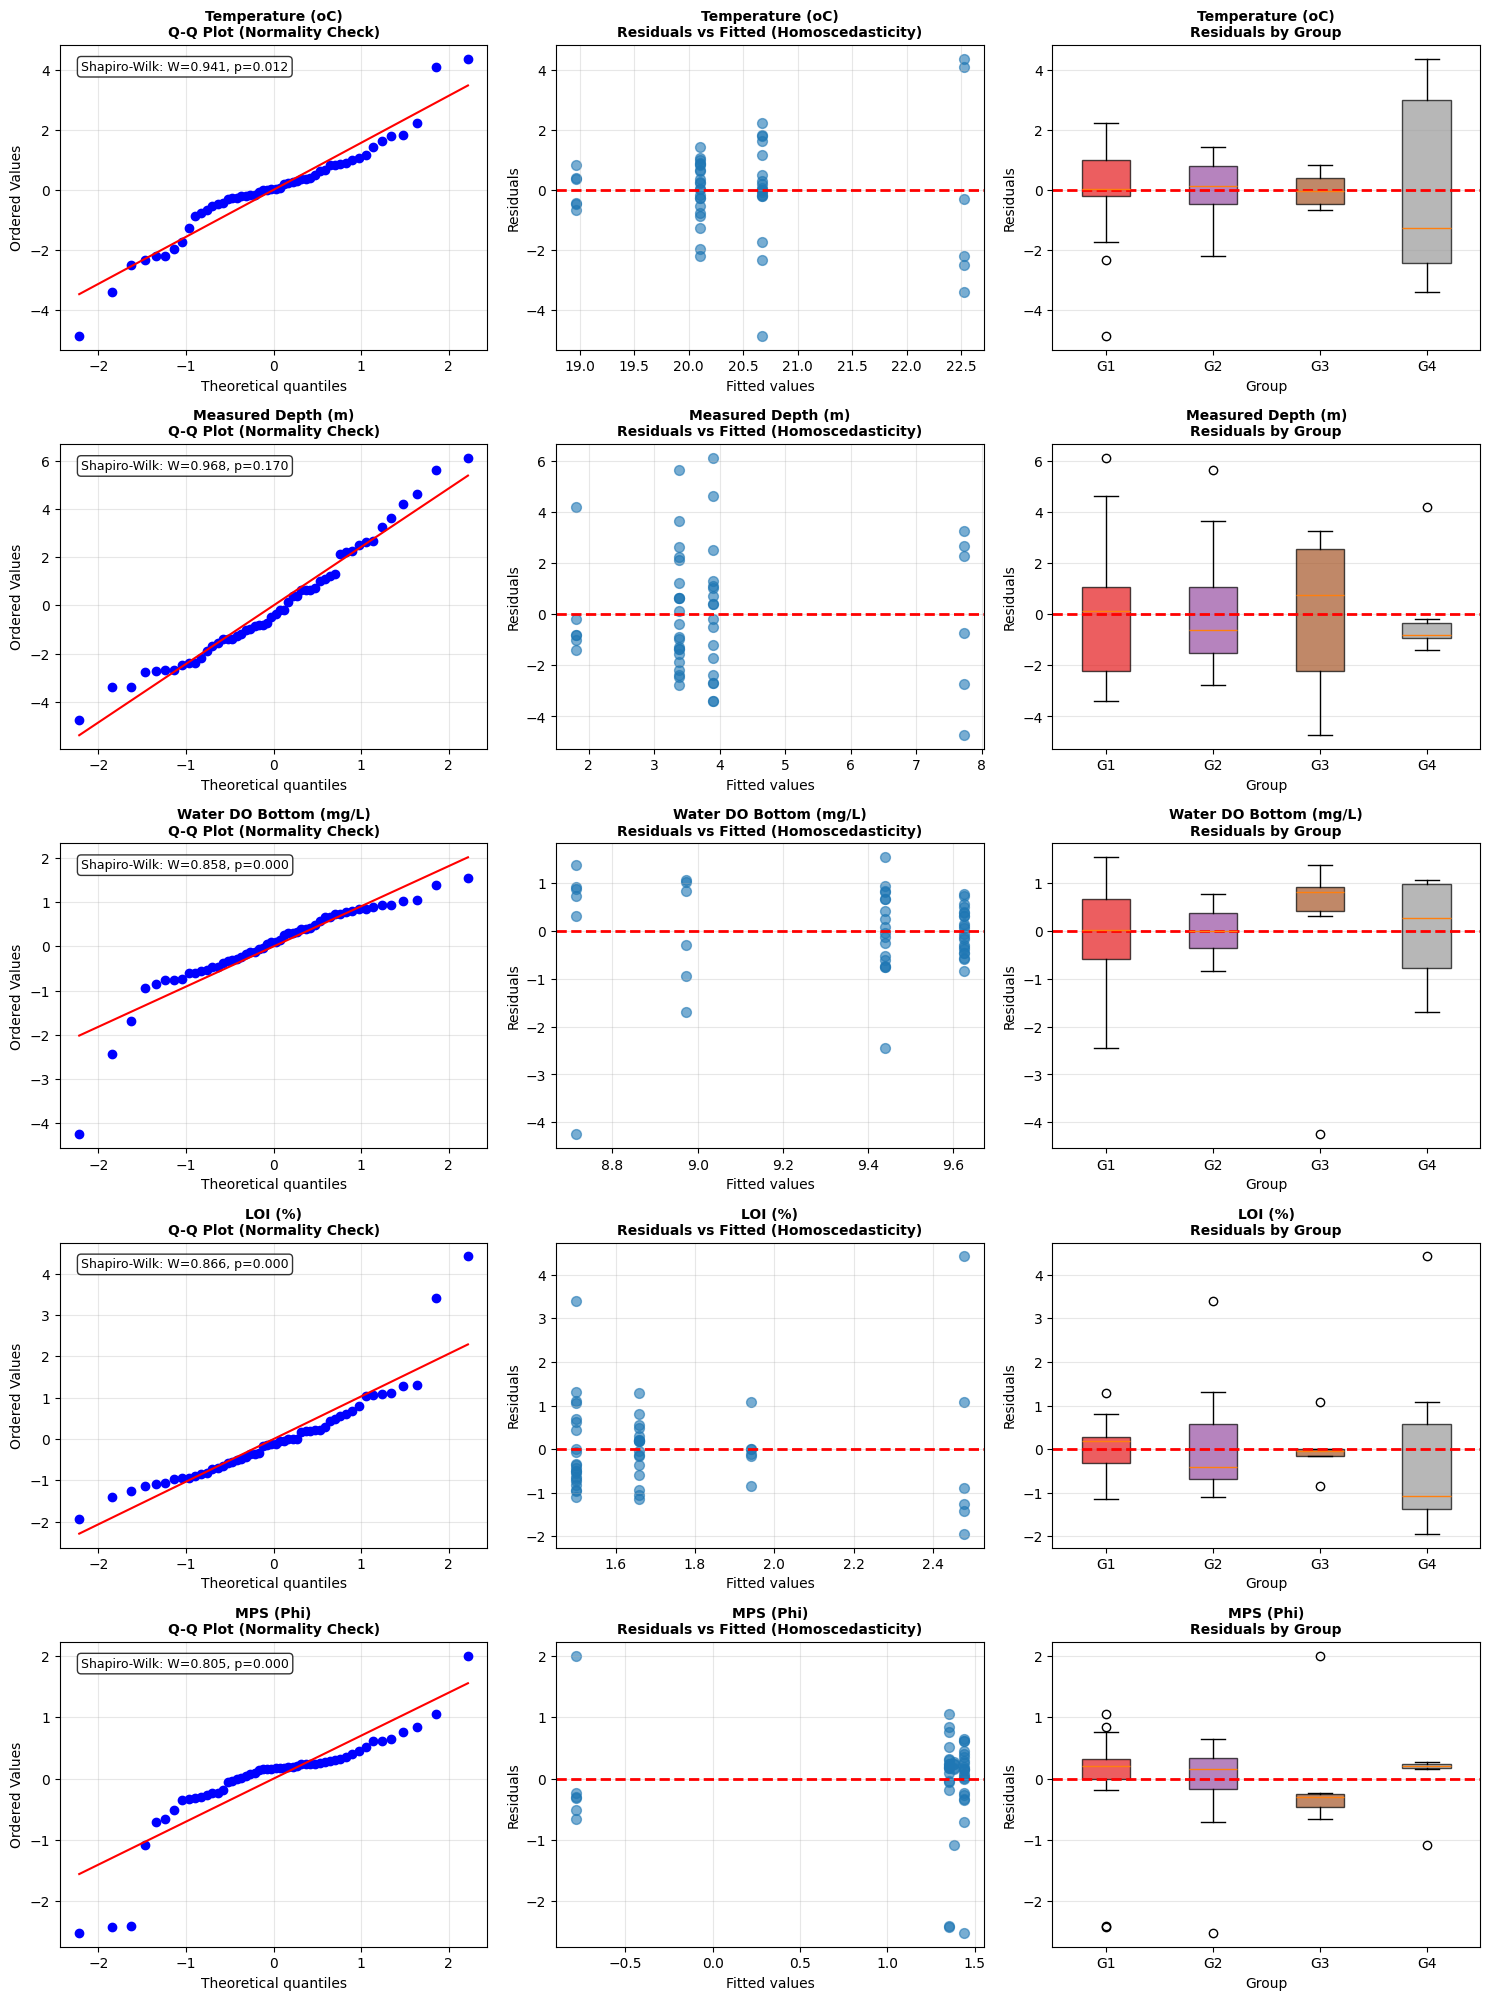

In [22]:
# Visualize ANOVA assumptions: Q-Q plots and residual plots
fig, axes = plt.subplots(len(env_features_anova), 3, figsize=(15, 4*len(env_features_anova)))

for idx, feature in enumerate(env_features_anova):
    # Get data by group
    groups_data = []
    for group_id in range(n_groups):
        group_values = raw_reference_data[raw_reference_data['hellinger_groups'] == group_id][feature].dropna()
        groups_data.append(group_values)
    
    # Calculate residuals
    group_means = [group.mean() for group in groups_data]
    residuals = []
    group_labels = []
    
    for group_id, group_data in enumerate(groups_data):
        group_residuals = group_data - group_means[group_id]
        residuals.extend(group_residuals)
        group_labels.extend([group_id] * len(group_residuals))
    
    residuals = np.array(residuals)
    group_labels = np.array(group_labels)
    
    # ========================================
    # Left: Q-Q Plot (Normality of Residuals)
    # ========================================
    ax1 = axes[idx, 0]
    # add Shapiro-Wilk test result on the plot
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    ax1.text(0.05, 0.95, f'Shapiro-Wilk: W={shapiro_stat:.3f}, p={shapiro_p:.3f}', 
             transform=ax1.transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    stats.probplot(residuals, dist="norm", plot=ax1)
    ax1.set_title(f'{feature}\nQ-Q Plot (Normality Check)', fontsize=10, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # ========================================
    # Middle: Residuals vs Fitted (Homoscedasticity)
    # ========================================
    ax2 = axes[idx, 1]
    fitted_values = np.concatenate([np.full(len(g), group_means[i]) for i, g in enumerate(groups_data)])
    
    ax2.scatter(fitted_values, residuals, alpha=0.6, s=50)
    ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax2.set_xlabel('Fitted values', fontsize=10)
    ax2.set_ylabel('Residuals', fontsize=10)
    ax2.set_title(f'{feature}\nResiduals vs Fitted (Homoscedasticity)', fontsize=10, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # ========================================
    # Right: Boxplot of residuals by group
    # ========================================
    ax3 = axes[idx, 2]
    residuals_by_group = [residuals[group_labels == i] for i in range(n_groups)]
    
    bp = ax3.boxplot(residuals_by_group, tick_labels=[f'G{i+1}' for i in range(n_groups)],
                     patch_artist=True)
    
    # Color boxes
    colors = plt.cm.Set1(np.linspace(0, 1, n_groups))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax3.set_xlabel('Group', fontsize=10)
    ax3.set_ylabel('Residuals', fontsize=10)
    ax3.set_title(f'{feature}\nResiduals by Group', fontsize=10, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.subplots_adjust(top=0.98)
plt.show()


#### Box-Cox transformation to the environmental features and check ANOVA assumptions again

Some raw habitat features do not meet the ANOVA assumptions well, especially the normality of residuals and homogeneity of variance.

Do some transformations (e.g., box-cox method) on the features to stabilize variance and distort the distribution then check the ANOVA assumptions again.

In [23]:
# apply Box-Cox transformation to habitat features to meet ANOVA assumptions
# Box-Cox finds optimal lambda parameter to normalize the data
from scipy.stats import boxcox
from scipy.special import inv_boxcox

# First, fetch the raw habitat feature data
for feature in env_features_anova:
    feature_data = raw_reference_data[feature].dropna()

print("\n" + "=" * 80)
print("Box-Cox Transformation Analysis")
print("=" * 80)

# Store Box-Cox transformed features and their lambda values
boxcox_features = {}
lambda_values = {}

for feature in env_features_anova:
    feature_data = raw_reference_data[feature].dropna()
    
    # Box-Cox requires all positive values
    # Shift the data if there are negative values or zeros
    if feature_data.min() <= 0:
        shift_value = abs(feature_data.min()) + 1
        shifted_data = feature_data + shift_value
        print(f"\n{feature}:")
        print(f"  - Contains non-positive values (min={feature_data.min():.3f})")
        print(f"  - Shifting by {shift_value:.3f} before Box-Cox transformation")

    else:
        shifted_data = feature_data
        shift_value = 0
        print(f"\n{feature}:")
        print(f"  - All values positive, no shifting needed")
    
    # Apply Box-Cox transformation and find optimal lambda
    try:
        transformed_data, optimal_lambda = boxcox(shifted_data)
        
        # Interpret lambda value
        if abs(optimal_lambda - 1.0) < 0.1:
            interpretation = "≈ No transformation needed"
        elif abs(optimal_lambda - 0.5) < 0.1:
            interpretation = "≈ Square root transformation"
        elif abs(optimal_lambda) < 0.1:
            interpretation = "≈ Log transformation"
        elif abs(optimal_lambda - (-1.0)) < 0.1:
            interpretation = "≈ Reciprocal transformation"
        else:
            interpretation = "Custom power transformation"

        # Create a Series with the same index as the original feature data
        transformed_series = pd.Series(transformed_data, index=feature_data.index)
        
        boxcox_features[feature] = {
            'data': transformed_series,
            'lambda': optimal_lambda,
            'shift': shift_value,
            'interpretation': interpretation
        }
        lambda_values[feature] = optimal_lambda
        
    except Exception as e:
        # Fall back to log transformation
        if shift_value > 0:
            transformed_data = np.log(shifted_data)
        else:
            transformed_data = np.log1p(feature_data)
        transformed_series = pd.Series(transformed_data, index=feature_data.index)
        boxcox_features[feature] = {
            'data': transformed_series,
            'lambda': 0.0,  # log transformation
            'shift': shift_value,
            'interpretation': "Log transformation (fallback)"
        }
        lambda_values[feature] = 0.0

# Add Box-Cox transformed features to raw_reference_data
print("\n" + "=" * 80)
print("Box-Cox Transformed Features Added to Dataset:")
print("=" * 80)
for feature in env_features_anova:
    transform_name = f'{feature}_boxcox_transformed'
    raw_reference_data[transform_name] = boxcox_features[feature]['data']
    lambda_val = boxcox_features[feature]['lambda']
    shift_val = boxcox_features[feature]['shift']
    interp = boxcox_features[feature]['interpretation']
    print(f"Added: {transform_name}")

print("\n✓ Box-Cox transformation completed for all habitat features")


Box-Cox Transformation Analysis

Temperature (oC):
  - All values positive, no shifting needed

Measured Depth (m):
  - All values positive, no shifting needed

Water DO Bottom (mg/L):
  - All values positive, no shifting needed

LOI (%):
  - All values positive, no shifting needed

MPS (Phi):
  - Contains non-positive values (min=-1.437)
  - Shifting by 2.437 before Box-Cox transformation

Box-Cox Transformed Features Added to Dataset:
Added: Temperature (oC)_boxcox_transformed
Added: Measured Depth (m)_boxcox_transformed
Added: Water DO Bottom (mg/L)_boxcox_transformed
Added: LOI (%)_boxcox_transformed
Added: MPS (Phi)_boxcox_transformed

✓ Box-Cox transformation completed for all habitat features


In [24]:
# re-run ANOVA assumptions assessment on Box-Cox transformed features
from scipy import stats
from scipy.stats import levene, shapiro, anderson

# List of Box-Cox transformed features
env_features_boxcox = [f'{feature}_boxcox_transformed' for feature in env_features_anova]

# Store results for summary
assumption_results_boxcox = []

for idx, feature_boxcox in enumerate(env_features_boxcox):
    original_feature = env_features_anova[idx]
    lambda_val = boxcox_features[original_feature]['lambda']
    
    # Get data by group
    groups_data = []
    for group_id in range(n_groups):
        group_values = raw_reference_data[raw_reference_data['hellinger_groups'] == group_id][feature_boxcox].dropna()
        groups_data.append(group_values)
    
    # Overall data
    all_values = raw_reference_data[feature_boxcox].dropna()
    
    # Fit ANOVA model to get residuals
    group_means = [group.mean() for group in groups_data]
    residuals = []
    
    for group_id, group_data in enumerate(groups_data):
        group_residuals = group_data - group_means[group_id]
        residuals.extend(group_residuals)
    
    residuals = np.array(residuals)
    
    # Shapiro-Wilk test on residuals
    if len(residuals) >= 3:
        shapiro_stat, shapiro_p = shapiro(residuals)
        normality_pass = shapiro_p > 0.05
    else:
        shapiro_stat, shapiro_p = np.nan, np.nan
        normality_pass = False
    
    # Levene's test
    levene_stat, levene_p = levene(*groups_data)
    variance_pass = levene_p > 0.05
    
    # Store results
    assumption_results_boxcox.append({
        'Feature': original_feature,
        'Transformed_Feature': feature_boxcox,
        'Lambda': lambda_val,
        'Shapiro_W': shapiro_stat,
        'Shapiro_p': shapiro_p,
        'Normality_Pass': normality_pass,
        'Levene_Stat': levene_stat,
        'Levene_p': levene_p,
        'Variance_Pass': variance_pass,
        'All_Assumptions_Pass': normality_pass and variance_pass
    })

In [25]:
# display the assessment summary in tabular format
# ==========================================

# Create DataFrames
results_boxcox_df = pd.DataFrame(assumption_results_boxcox)
results_original_df = pd.DataFrame(assumption_results)

print("\n\n")
print("=" * 130)
print("BOX-COX TRANSFORMATION ANALYSIS RESULTS")
print("=" * 130)

# Table 1: Lambda Values and Transformations
print("\n┌─ TABLE 1: Optimal Lambda Values and Transformation Types ─────────────────────────────────────┐")
print(f"│ {'Feature':<25} │ {'Lambda (λ)':<12} │ {'Shift':<8} │ {'Transformation Type':<35} │")
print("├" + "─" * 26 + "┼" + "─" * 14 + "┼" + "─" * 10 + "┼" + "─" * 37 + "┤")
for result in assumption_results_boxcox:
    feature = result['Feature'][:25]
    lambda_val = result['Lambda']
    shift = boxcox_features[result['Feature']]['shift']
    interp = boxcox_features[result['Feature']]['interpretation'][:35]
    print(f"│ {feature:<25} │ {lambda_val:>12.4f} │ {shift:>8.2f} │ {interp:<35} │")
print("└" + "─" * 26 + "┴" + "─" * 14 + "┴" + "─" * 10 + "┴" + "─" * 37 + "┘")

# Table 2: Detailed Test Statistics
print("\n┌─ TABLE 2: ANOVA Assumption Test Statistics ───────────────────────────────────────────────────┐")
print(f"│ {'Feature':<25} │ {'Shapiro-W':<10} │ {'p-value':<9} │ {'Levene':<10} │ {'p-value':<9} │ {'Pass':<5} │")
print("├" + "─" * 26 + "┼" + "─" * 12 + "┼" + "─" * 11 + "┼" + "─" * 12 + "┼" + "─" * 11 + "┼" + "─" * 7 + "┤")
for _, row in results_boxcox_df.iterrows():
    feature = row['Feature'][:25]
    shapiro_w = row['Shapiro_W']
    shapiro_p = row['Shapiro_p']
    levene_stat = row['Levene_Stat']
    levene_p = row['Levene_p']
    pass_status = "✓ Yes" if row['All_Assumptions_Pass'] else "✗ No"
    print(f"│ {feature:<25} │ {shapiro_w:>10.3f} │ {shapiro_p:>9.3f} │ {levene_stat:>10.3f} │ {levene_p:>9.3f} │ {pass_status:<5} │")
print("└" + "─" * 26 + "┴" + "─" * 12 + "┴" + "─" * 11 + "┴" + "─" * 12 + "┴" + "─" * 11 + "┴" + "─" * 7 + "┘")

# Table 3: Comparison Summary
print("\n┌─ TABLE 3: Comparison Summary (Original vs Box-Cox) ───────────────────────────────────────────┐")
print(f"│ {'Feature':<25} │ {'Original':<15} │ {'Box-Cox':<15} │ {'Status':<12} │")
print(f"│ {'':>25} │ {'N   V  All':<15} │ {'N   V  All':<15} │ {'':>12} │")
print("├" + "─" * 26 + "┼" + "─" * 17 + "┼" + "─" * 17 + "┼" + "─" * 14 + "┤")

for idx, row_orig in results_original_df.iterrows():
    row_bc = results_boxcox_df.iloc[idx]
    feature = row_orig['Feature'][:25]
    
    # Original
    orig_n = "✓" if row_orig['Normality_Pass'] else "✗"
    orig_v = "✓" if row_orig['Variance_Pass'] else "✗"
    orig_a = "✓" if row_orig['All_Assumptions_Pass'] else "✗"
    
    # Box-Cox
    bc_n = "✓" if row_bc['Normality_Pass'] else "✗"
    bc_v = "✓" if row_bc['Variance_Pass'] else "✗"
    bc_a = "✓" if row_bc['All_Assumptions_Pass'] else "✗"
    
    # Status
    if row_bc['All_Assumptions_Pass'] and not row_orig['All_Assumptions_Pass']:
        status = "✓ Improved"
    elif row_bc['All_Assumptions_Pass'] == row_orig['All_Assumptions_Pass']:
        status = "─ Same"
    else:
        status = "✗ Worse"
    
    print(f"│ {feature:<25} │ {orig_n}   {orig_v}   {orig_a}     │ {bc_n}   {bc_v}   {bc_a}     │ {status:<12} │")

print("├" + "─" * 26 + "┼" + "─" * 17 + "┼" + "─" * 17 + "┼" + "─" * 14 + "┤")
print(f"│ {'TOTALS':<25} │ {'':>17} │ {'':>17} │ {'':>14} │")

orig_n_total = results_original_df['Normality_Pass'].sum()
orig_v_total = results_original_df['Variance_Pass'].sum()
orig_a_total = results_original_df['All_Assumptions_Pass'].sum()

bc_n_total = results_boxcox_df['Normality_Pass'].sum()
bc_v_total = results_boxcox_df['Variance_Pass'].sum()
bc_a_total = results_boxcox_df['All_Assumptions_Pass'].sum()

print(f"│ {'Normality passed':<25} │ {orig_n_total:>17} │ {bc_n_total:>17} │ {'+' + str(bc_n_total - orig_n_total) if bc_n_total > orig_n_total else str(bc_n_total - orig_n_total):>14} │")
print(f"│ {'Homogeneity passed':<25} │ {orig_v_total:>17} │ {bc_v_total:>17} │ {'+' + str(bc_v_total - orig_v_total) if bc_v_total > orig_v_total else str(bc_v_total - orig_v_total):>14} │")
print(f"│ {'ALL assumptions passed':<25} │ {orig_a_total:>17} │ {bc_a_total:>17} │ {'+' + str(bc_a_total - orig_a_total) if bc_a_total > orig_a_total else str(bc_a_total - orig_a_total):>14} │")
print("└" + "─" * 26 + "┴" + "─" * 17 + "┴" + "─" * 17 + "┴" + "─" * 14 + "┘")

print(f"\nNote: N=Normality, V=Variance/Homogeneity, All=Both assumptions")
print("=" * 130)
    
# Shapiro-Wilk test on residuals
if len(residuals) >= 3:
    shapiro_stat, shapiro_p = shapiro(residuals)
    
    if shapiro_p > 0.05:
        normality_pass = True
    else:
        normality_pass = False
else:
    shapiro_stat, shapiro_p = np.nan, np.nan
    normality_pass = False

# Anderson-Darling test on residuals
anderson_result = anderson(residuals, dist='norm')

# Check normality for each group
group_normality = []
for group_id, group_data in enumerate(groups_data):
    if len(group_data) >= 3:
        sw_stat, sw_p = shapiro(group_data)
        group_normality.append(sw_p > 0.05)
        status = "✓" if sw_p > 0.05 else "✗"
    else:
        group_normality.append(False)
    
    # ========================================
    # 2. HOMOGENEITY OF VARIANCE (Levene's test)
    # ========================================
    
    # Levene's test
    levene_stat, levene_p = levene(*groups_data)
    if levene_p > 0.05:
        variance_pass = True
    else:
        variance_pass = False
    
    # Store results
    assumption_results_boxcox.append({
        'Feature': original_feature,
        'Transformed_Feature': feature_boxcox,
        'Lambda': lambda_val,
        'Shapiro_W': shapiro_stat,
        'Shapiro_p': shapiro_p,
        'Normality_Pass': normality_pass,
        'Levene_Stat': levene_stat,
        'Levene_p': levene_p,
        'Variance_Pass': variance_pass,
        'All_Assumptions_Pass': normality_pass and variance_pass
    })

# Generate comprehensive LaTeX tables with summary and comparison
import os

# Create DataFrames for analysis
results_boxcox_df = pd.DataFrame(assumption_results_boxcox)
results_original_df = pd.DataFrame(assumption_results)

# Print single consolidated table
print("\n\n")
print("=" * 120)
print("ANOVA ASSUMPTIONS ASSESSMENT RESULTS: Original vs Box-Cox Transformed Features")
print("=" * 120)
print(f"\n{'Feature':<25} {'λ':<8} {'─── Original ───':<20} {'─── Box-Cox ───':<20} {'Status':<12}")
print(f"{'':>25} {'':>8} {'N    V    All':<20} {'N    V    All':<20} {'':>12}")
print("-" * 120)

for idx, row_orig in results_original_df.iterrows():
    row_bc = results_boxcox_df.iloc[idx]
    
    # Original results
    orig_norm = "✓" if row_orig['Normality_Pass'] else "✗"
    orig_var = "✓" if row_orig['Variance_Pass'] else "✗"
    orig_all = "✓" if row_orig['All_Assumptions_Pass'] else "✗"
    
    # Box-Cox results
    bc_norm = "✓" if row_bc['Normality_Pass'] else "✗"
    bc_var = "✓" if row_bc['Variance_Pass'] else "✗"
    bc_all = "✓" if row_bc['All_Assumptions_Pass'] else "✗"
    
    # Improvement indicator
    if row_bc['All_Assumptions_Pass'] and not row_orig['All_Assumptions_Pass']:
        status = "✓ Improved"
    elif row_bc['All_Assumptions_Pass'] == row_orig['All_Assumptions_Pass']:
        status = "─ Same"
    else:
        status = "✗ Worse"
    
    print(f"{row_orig['Feature']:<25} {row_bc['Lambda']:<8.3f} "
          f"{orig_norm}    {orig_var}    {orig_all}        "
          f"{bc_norm}    {bc_var}    {bc_all}        "
          f"{status:<12}")

print("-" * 120)
print(f"{'SUMMARY':<25} {'':>8} {'':>20} {'':>20} {'':>12}")
print("-" * 120)
print(f"{'Normality passed':<25} {'':>8} {results_original_df['Normality_Pass'].sum():<20} "
      f"{results_boxcox_df['Normality_Pass'].sum():<20} "
      f"{'(+' + str(results_boxcox_df['Normality_Pass'].sum() - results_original_df['Normality_Pass'].sum()) + ')' if results_boxcox_df['Normality_Pass'].sum() > results_original_df['Normality_Pass'].sum() else ''}")
print(f"{'Homogeneity passed':<25} {'':>8} {results_original_df['Variance_Pass'].sum():<20} "
      f"{results_boxcox_df['Variance_Pass'].sum():<20} "
      f"{'(+' + str(results_boxcox_df['Variance_Pass'].sum() - results_original_df['Variance_Pass'].sum()) + ')' if results_boxcox_df['Variance_Pass'].sum() > results_original_df['Variance_Pass'].sum() else ''}")
print(f"{'ALL assumptions passed':<25} {'':>8} {results_original_df['All_Assumptions_Pass'].sum():<20} "
      f"{results_boxcox_df['All_Assumptions_Pass'].sum():<20} "
      f"{'(+' + str(results_boxcox_df['All_Assumptions_Pass'].sum() - results_original_df['All_Assumptions_Pass'].sum()) + ')' if results_boxcox_df['All_Assumptions_Pass'].sum() > results_original_df['All_Assumptions_Pass'].sum() else ''}")
print("=" * 120)
print(f"Note: N=Normality, V=Variance/Homogeneity, All=Both assumptions passed")




BOX-COX TRANSFORMATION ANALYSIS RESULTS

┌─ TABLE 1: Optimal Lambda Values and Transformation Types ─────────────────────────────────────┐
│ Feature                   │ Lambda (λ)   │ Shift    │ Transformation Type                 │
├──────────────────────────┼──────────────┼──────────┼─────────────────────────────────────┤
│ Temperature (oC)          │      -1.1693 │     0.00 │ Custom power transformation         │
│ Measured Depth (m)        │       0.2625 │     0.00 │ Custom power transformation         │
│ Water DO Bottom (mg/L)    │       5.3051 │     0.00 │ Custom power transformation         │
│ LOI (%)                   │      -0.0152 │     0.00 │ ≈ Log transformation                │
│ MPS (Phi)                 │       3.0670 │     2.44 │ Custom power transformation         │
└──────────────────────────┴──────────────┴──────────┴─────────────────────────────────────┘

┌─ TABLE 2: ANOVA Assumption Test Statistics ───────────────────────────────────────────────────┐
│ Feature

In [26]:
# save the summary to local result file in latex table
# ==========================================
output_dir = "../results/tables/03_Taxa_Assemblages_Cluster"
os.makedirs(output_dir, exist_ok=True)

# Calculate summary statistics
norm_pass_count_bc = sum([r['Normality_Pass'] for r in assumption_results_boxcox])
var_pass_count_bc = sum([r['Variance_Pass'] for r in assumption_results_boxcox])
all_pass_count_bc = sum([r['All_Assumptions_Pass'] for r in assumption_results_boxcox])
total_features = len(assumption_results_boxcox)

norm_pass_count_orig = sum([r['Normality_Pass'] for r in assumption_results])
var_pass_count_orig = sum([r['Variance_Pass'] for r in assumption_results])
all_pass_count_orig = sum([r['All_Assumptions_Pass'] for r in assumption_results])

# Generate LaTeX content
latex_content = r"""\documentclass{article}
\usepackage{booktabs}
\usepackage{longtable}
\usepackage{array}
\usepackage{geometry}
\usepackage{xcolor}
\usepackage{textcomp}
\geometry{margin=1in}

\begin{document}

\title{ANOVA Assumptions Assessment for Box-Cox Transformed Habitat Features}
\author{Taxa Assemblage Groups Analysis}
\date{\today}
\maketitle

\section{Main Results Table}

\begin{longtable}{p{2.8cm}ccccccc}
\caption{Assessment of ANOVA Assumptions for Box-Cox Transformed Environmental Features} \\
\toprule
\textbf{Feature} & \textbf{$\lambda$} & \textbf{Shapiro-W} & \textbf{p-value} & \textbf{Normality} & \textbf{Levene's} & \textbf{p-value} & \textbf{Homog.} \\
\midrule
\endfirsthead

\multicolumn{8}{c}{\tablename\ \thetable\ -- \textit{Continued from previous page}} \\
\toprule
\textbf{Feature} & \textbf{$\lambda$} & \textbf{Shapiro-W} & \textbf{p-value} & \textbf{Normality} & \textbf{Levene's} & \textbf{p-value} & \textbf{Homog.} \\
\midrule
\endhead

\midrule
\multicolumn{8}{r}{\textit{Continued on next page}} \\
\endfoot

\bottomrule
\endlastfoot

"""

# Add main results data rows
for result in assumption_results_boxcox:
    feature = result['Feature']
    feature_clean = feature.replace('(oC)', r'(\textdegree{}C)').replace('%', r'\%')
    # Shorten long feature names
    if 'Water DO' in feature_clean:
        feature_clean = feature_clean.replace('Water DO Bottom', 'DO Bottom')
    if 'Measured' in feature_clean:
        feature_clean = feature_clean.replace('Measured ', '')
    
    lambda_val = result['Lambda']
    shapiro_w = result['Shapiro_W']
    shapiro_p = result['Shapiro_p']
    norm_pass = r'\textcolor{green}{PASS}' if result['Normality_Pass'] else r'\textcolor{red}{FAIL}'
    
    levene_stat = result['Levene_Stat']
    levene_p = result['Levene_p']
    var_pass = r'\textcolor{green}{PASS}' if result['Variance_Pass'] else r'\textcolor{red}{FAIL}'
    
    latex_content += f"{feature_clean} & {lambda_val:.3f} & {shapiro_w:.3f} & {shapiro_p:.3f} & {norm_pass} & {levene_stat:.3f} & {levene_p:.3f} & {var_pass} \\\\\n"

latex_content += r"""
\end{longtable}

\section{Summary Statistics}

\begin{table}[h]
\centering
\caption{Summary of Assumption Test Results: Box-Cox vs Original}
\begin{tabular}{lcc}
\toprule
\textbf{Metric} & \textbf{Original} & \textbf{Box-Cox} \\
\midrule
Total features tested & """ + str(total_features) + r""" & """ + str(total_features) + r""" \\
Normality assumption passed & """ + str(norm_pass_count_orig) + r""" & """ + str(norm_pass_count_bc) + r""" \\
Homogeneity assumption passed & """ + str(var_pass_count_orig) + r""" & """ + str(var_pass_count_bc) + r""" \\
\textbf{All assumptions passed} & \textbf{""" + str(all_pass_count_orig) + r"""} & \textbf{""" + str(all_pass_count_bc) + r"""} \\
\bottomrule
\end{tabular}
\end{table}

\section{Detailed Comparison by Feature}

\begin{table}[h]
\centering
\caption{Feature-by-Feature Comparison: Original vs Box-Cox Transformed}
\begin{tabular}{p{4cm}ccc}
\toprule
\textbf{Feature} & \textbf{Original} & \textbf{Box-Cox} & \textbf{Result} \\
\midrule
"""

# Add comparison rows
for idx, row_orig in results_original_df.iterrows():
    row_bc = results_boxcox_df.iloc[idx]
    feature = row_orig['Feature']
    feature_clean = feature.replace('(oC)', r'(\textdegree{}C)').replace('%', r'\%')
    if 'Water DO' in feature_clean:
        feature_clean = feature_clean.replace('Water DO Bottom', 'DO Bottom')
    if 'Measured' in feature_clean:
        feature_clean = feature_clean.replace('Measured ', '')
    
    orig_pass = r'\textcolor{green}{PASS}' if row_orig['All_Assumptions_Pass'] else r'\textcolor{red}{FAIL}'
    bc_pass = r'\textcolor{green}{PASS}' if row_bc['All_Assumptions_Pass'] else r'\textcolor{red}{FAIL}'
    
    if row_bc['All_Assumptions_Pass'] and not row_orig['All_Assumptions_Pass']:
        result = r'\textcolor{blue}{Improved}'
    elif row_bc['All_Assumptions_Pass'] == row_orig['All_Assumptions_Pass']:
        result = 'Same'
    else:
        result = r'\textcolor{orange}{Worse}'
    
    latex_content += f"{feature_clean} & {orig_pass} & {bc_pass} & {result} \\\\\n"

latex_content += r"""
\bottomrule
\end{tabular}
\end{table}

\section{Box-Cox Transformation Details}

The Box-Cox transformation is defined as:
\[
y(\lambda) = 
\begin{cases}
\frac{x^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \\
\log(x) & \text{if } \lambda = 0
\end{cases}
\]

\subsection{Optimal Lambda Values and Interpretations}

\begin{itemize}
"""

# Add lambda interpretation for each feature
for result in assumption_results_boxcox:
    feature = result['Feature']
    feature_clean = feature.replace('(oC)', r'(\textdegree{}C)').replace('%', r'\%')
    lambda_val = result['Lambda']
    shift_val = boxcox_features[feature]['shift']
    interp = boxcox_features[feature]['interpretation']
    
    latex_content += f"    \\item \\textbf{{{feature_clean}}}: $\\lambda$ = {lambda_val:.4f}"
    if shift_val > 0:
        latex_content += f" (shifted by {shift_val:.2f})"
    latex_content += f" --- {interp}\n"

latex_content += r"""
\end{itemize}

\section{Methodology Notes}

\begin{itemize}
    \item \textbf{Normality}: Assessed using Shapiro-Wilk test on ANOVA residuals (p $>$ 0.05 indicates normality)
    \item \textbf{Homogeneity of Variance}: Assessed using Levene's test (p $>$ 0.05 indicates homogeneous variances)
    \item \textbf{Independence}: Assumed based on spatial separation of sampling sites
    \item \textbf{Box-Cox Method}: Automatically finds optimal $\lambda$ to maximize normality of the transformed data
    \item \textbf{Shifting}: Features with non-positive values were shifted by $|\text{min}| + 1$ before transformation
    \item \textbf{Groups}: """ + str(n_groups) + r""" taxa assemblage groups identified by Ward's hierarchical clustering
\end{itemize}

\end{document}
"""

# Save to file
# output_file = os.path.join(output_dir, "anova_assumptions_assessment_boxcox_transformed_habitat_features.tex")
# with open(output_file, 'w') as f:
#     f.write(latex_content)

# print(f"\n{'=' * 100}")
# print(f"✓ LaTeX document saved to: {output_file}")
# print(f"{'=' * 100}")
# print(f"\nDocument includes:")
# print(f"  1. Main results table with all test statistics")
# print(f"  2. Summary statistics comparing original vs Box-Cox")
# print(f"  3. Feature-by-feature comparison table")
# print(f"  4. Lambda values with interpretations")
# print(f"  5. Methodology notes")
# print(f"\nOverall improvement: {all_pass_count_bc - all_pass_count_orig} features now pass all assumptions")

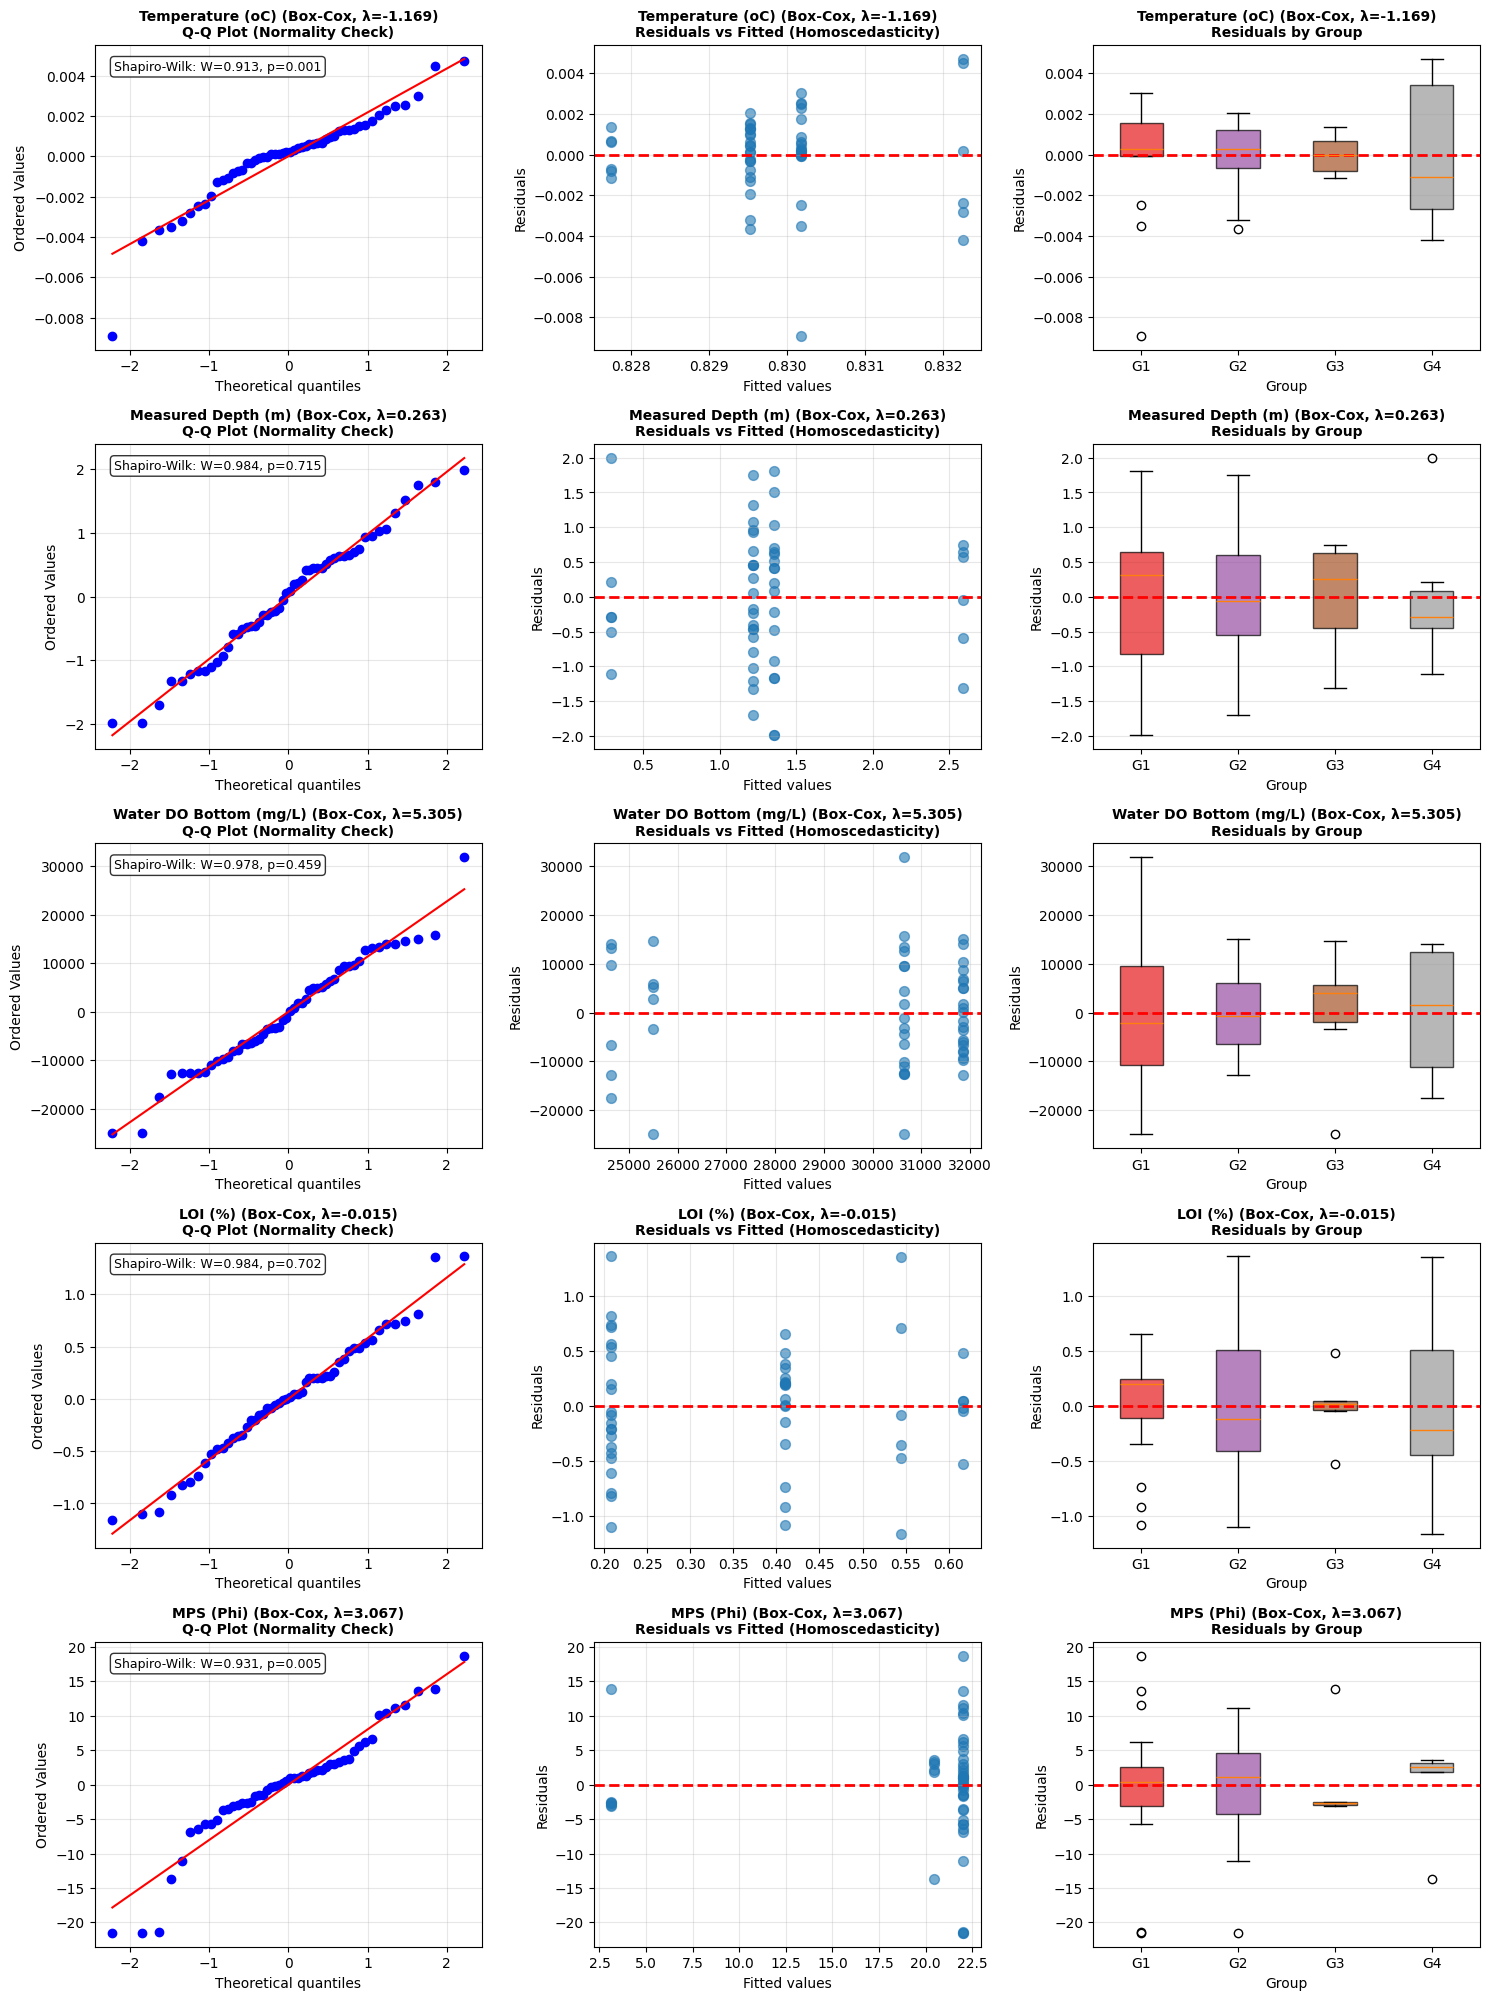

In [27]:
# visualize the asumption assessment for the Box-Cox transformed features
fig, axes = plt.subplots(len(env_features_anova), 3, figsize=(15, 4*len(env_features_anova)))

for idx, feature_boxcox in enumerate(env_features_boxcox):
    original_feature = env_features_anova[idx]
    lambda_val = boxcox_features[original_feature]['lambda']
    
    # Get data by group
    groups_data = []
    for group_id in range(n_groups):
        group_values = raw_reference_data[raw_reference_data['hellinger_groups'] == group_id][feature_boxcox].dropna()
        groups_data.append(group_values)
    
    # Calculate residuals
    group_means = [group.mean() for group in groups_data]
    residuals = []
    group_labels = []
    
    for group_id, group_data in enumerate(groups_data):
        group_residuals = group_data - group_means[group_id]
        residuals.extend(group_residuals)
        group_labels.extend([group_id] * len(group_residuals))
    
    residuals = np.array(residuals)
    group_labels = np.array(group_labels)
    
    # ========================================
    # Left: Q-Q Plot (Normality of Residuals)
    # ========================================
    ax1 = axes[idx, 0]
    # add Shapiro-Wilk test result on the plot
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    ax1.text(0.05, 0.95, f'Shapiro-Wilk: W={shapiro_stat:.3f}, p={shapiro_p:.3f}', 
             transform=ax1.transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    stats.probplot(residuals, dist="norm", plot=ax1)
    ax1.set_title(f'{original_feature} (Box-Cox, λ={lambda_val:.3f})\nQ-Q Plot (Normality Check)', 
                  fontsize=10, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # ========================================
    # Middle: Residuals vs Fitted (Homoscedasticity)
    # ========================================
    ax2 = axes[idx, 1]
    fitted_values = np.concatenate([np.full(len(g), group_means[i]) for i, g in enumerate(groups_data)])
    
    ax2.scatter(fitted_values, residuals, alpha=0.6, s=50)
    ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax2.set_xlabel('Fitted values', fontsize=10)
    ax2.set_ylabel('Residuals', fontsize=10)
    ax2.set_title(f'{original_feature} (Box-Cox, λ={lambda_val:.3f})\nResiduals vs Fitted (Homoscedasticity)', 
                  fontsize=10, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # ========================================
    # Right: Boxplot of residuals by group
    # ========================================
    ax3 = axes[idx, 2]
    residuals_by_group = [residuals[group_labels == i] for i in range(n_groups)]
    
    bp = ax3.boxplot(residuals_by_group, tick_labels=[f'G{i+1}' for i in range(n_groups)],
                     patch_artist=True)
    
    # Color boxes
    colors = plt.cm.Set1(np.linspace(0, 1, n_groups))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax3.set_xlabel('Group', fontsize=10)
    ax3.set_ylabel('Residuals', fontsize=10)
    ax3.set_title(f'{original_feature} (Box-Cox, λ={lambda_val:.3f})\nResiduals by Group', 
                  fontsize=10, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.subplots_adjust(top=0.98)
plt.show()

Based on the **Box-Cox** transformation, though some features still did not fully meet the ANOVA assumptions, overall the assumptions are much better satisfied than before transformation.

Therefore, we can proceed to do ANOVA on the Box-Cox transformed habitat features across the clusters.

#### ANOVA on Box-Cox transformed habitat features across the clusters

In [28]:
from scipy.stats import f_oneway

# Perform ANOVA on Box-Cox transformed features across the taxa assemblage groups
print("=" * 120)
print("ONE-WAY ANOVA: Box-Cox Transformed Habitat Features Across Taxa Assemblage Groups")
print("=" * 120)
print(f"\nNull Hypothesis (H₀): Group means are equal for each environmental feature")
print(f"Alternative Hypothesis (H₁): At least one group mean differs")
print(f"Significance level: α = 0.05")
print(f"\nNumber of groups: {n_groups}")
print(f"Total sites: {len(raw_reference_data)}")
print(f"Sites per group: {cluster_groups.value_counts().sort_index().to_dict()}")

# Store ANOVA results
anova_results = []

for idx, feature_boxcox in enumerate(env_features_boxcox):
    original_feature = env_features_anova[idx]
    
    # Get data by group
    groups_data = []
    for group_id in range(n_groups):
        group_values = raw_reference_data[raw_reference_data['hellinger_groups'] == group_id][feature_boxcox].dropna()
        groups_data.append(group_values)
    
    # Perform one-way ANOVA
    f_stat, p_value = f_oneway(*groups_data)
    
    # Determine significance
    is_significant = p_value < 0.05
    
    # Store results
    anova_results.append({
        'Original_Feature': original_feature,
        'Transformed_Feature': feature_boxcox,
        'F_statistic': f_stat,
        'p_value': p_value,
        'Significant': is_significant
    })

# Create compact table output
anova_df = pd.DataFrame(anova_results)

# Table: ANOVA Results
print("\n┌─ ANOVA Results: Box-Cox Transformed Features ─" + "─" * 70 + "┐")
print("│")
print("│  Feature                     │  F-statistic │  p-value   │  Significant  │")
print("│" + "─" * 30 + "┼" + "─" * 14 + "┼" + "─" * 12 + "┼" + "─" * 15 + "│")

for _, row in anova_df.iterrows():
    feature_short = row['Original_Feature'][:27] + '...' if len(row['Original_Feature']) > 27 else row['Original_Feature']
    sig_mark = "✓ (p < 0.05)" if row['Significant'] else "✗ (p ≥ 0.05)"
    print(f"│  {feature_short:<28} │  {row['F_statistic']:>10.4f}  │  {row['p_value']:>8.4f}  │  {sig_mark:<13} │")

print("│")
print("└" + "─" * 118 + "┘")

# Summary
n_significant = anova_df['Significant'].sum()
n_total = len(anova_df)

print(f"\n┌─ ANOVA Summary ─" + "─" * 20 + "┐")
print("│")
print(f"│  Significant differences: {n_significant}/{n_total}   │")
print("│")
print("└" + "─" * 38 + "┘")

print("\nInterpretation:")
if n_significant > 0:
    print(f"  • {n_significant} feature(s) show significant differences across taxa assemblage groups (p < 0.05)")
    print(f"  • These features may be important environmental drivers of taxa assemblage structure")
else:
    print(f"  • No features show significant differences across groups")
    print(f"  • Taxa assemblages may be driven by other factors not measured here")

ONE-WAY ANOVA: Box-Cox Transformed Habitat Features Across Taxa Assemblage Groups

Null Hypothesis (H₀): Group means are equal for each environmental feature
Alternative Hypothesis (H₁): At least one group mean differs
Significance level: α = 0.05

Number of groups: 4
Total sites: 52
Sites per group: {0: 18, 1: 22, 2: 6, 3: 6}

┌─ ANOVA Results: Box-Cox Transformed Features ───────────────────────────────────────────────────────────────────────┐
│
│  Feature                     │  F-statistic │  p-value   │  Significant  │
│──────────────────────────────┼──────────────┼────────────┼───────────────│
│  Temperature (oC)             │      4.0838  │    0.0116  │  ✓ (p < 0.05)  │
│  Measured Depth (m)           │      5.5285  │    0.0024  │  ✓ (p < 0.05)  │
│  Water DO Bottom (mg/L)       │      0.9376  │    0.4299  │  ✗ (p ≥ 0.05)  │
│  LOI (%)                      │      1.1078  │    0.3552  │  ✗ (p ≥ 0.05)  │
│  MPS (Phi)                    │      8.8242  │    0.0001  │  ✓ (p < 0.05)  │